In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Global plot styling (applies to all figures below)
plt.rcParams.update(
    {
        "figure.titlesize": 16,
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 14,
        "legend.title_fontsize": 15,
    }
)

results_path = Path("saebench_results.json")

with results_path.open() as f:
    records = json.load(f)

len(records), type(records)

(126, list)

In [2]:
X_KEY = "core||sparsity||l0"
Y_KEY = "core||model_performance_preservation||ce_loss_score"

# --- SAEBench aggregated results (saebench_results.json) ---
rows = []
for r in records:
    rows.append(
        {
            "modelId": r.get("modelId"),
            "sourceId": r.get("sourceId"),
            "release": r.get("release"),
            "layer": r.get("layer"),
            "saeClass": r.get("saeClass"),
            "dSae": r.get("dSae"),
            "trainingTokens": r.get("trainingTokens"),
            "l0": r.get(X_KEY),
            "ce_loss_score": r.get(Y_KEY),
        }
    )

df_main = pd.DataFrame(rows)

# --- Idempotent core runs (eval_results/core/Idempotent*.json) ---
idem_rows = []
idem_dir = Path("eval_results/core")

def _infer_dsae_from_name(name: str):
    name_l = name.lower()
    if "_4k_" in name_l:
        return 4096
    if "_16k_" in name_l:
        return 16384
    if "_64k_" in name_l or "_65k_" in name_l:
        return 65536
    return np.nan

for p in sorted(idem_dir.glob("Idempotent*.json")):
    with p.open() as f:
        j = json.load(f)

    metrics = (j or {}).get("eval_result_metrics", {})

    l0 = ((metrics.get("sparsity", {}) or {}).get("l0"))
    ce = (
        (metrics.get("model_performance_preservation", {}) or {}).get("ce_loss_score")
    )

    idem_rows.append(
        {
            "modelId": ((j or {}).get("eval_config", {}) or {}).get("model_name"),
            "sourceId": p.name,
            "release": "idempotent_core",
            "layer": np.nan,
            "saeClass": p.stem.split("_")[0],
            "dSae": _infer_dsae_from_name(p.name),
            "trainingTokens": np.nan,
            "l0": l0,
            "ce_loss_score": ce,
        }
    )

df_idem_core = pd.DataFrame(idem_rows)

# Combine
df = pd.concat([df_main, df_idem_core], ignore_index=True)

df["l0"] = pd.to_numeric(df["l0"], errors="coerce")
df["ce_loss_score"] = pd.to_numeric(df["ce_loss_score"], errors="coerce")
df["dSae"] = pd.to_numeric(df["dSae"], errors="coerce")

df_plot = df.dropna(subset=["l0", "ce_loss_score", "dSae"]).copy()

df_plot.shape, df_plot[["l0", "ce_loss_score"]].describe()

((162, 9),
                 l0  ce_loss_score
 count   162.000000     162.000000
 mean    279.273174       0.982762
 std     297.425929       0.017770
 min      19.433346       0.897561
 25%      52.742581       0.977236
 50%     159.515617       0.988487
 75%     410.581993       0.995066
 max    1262.171875       1.000000)

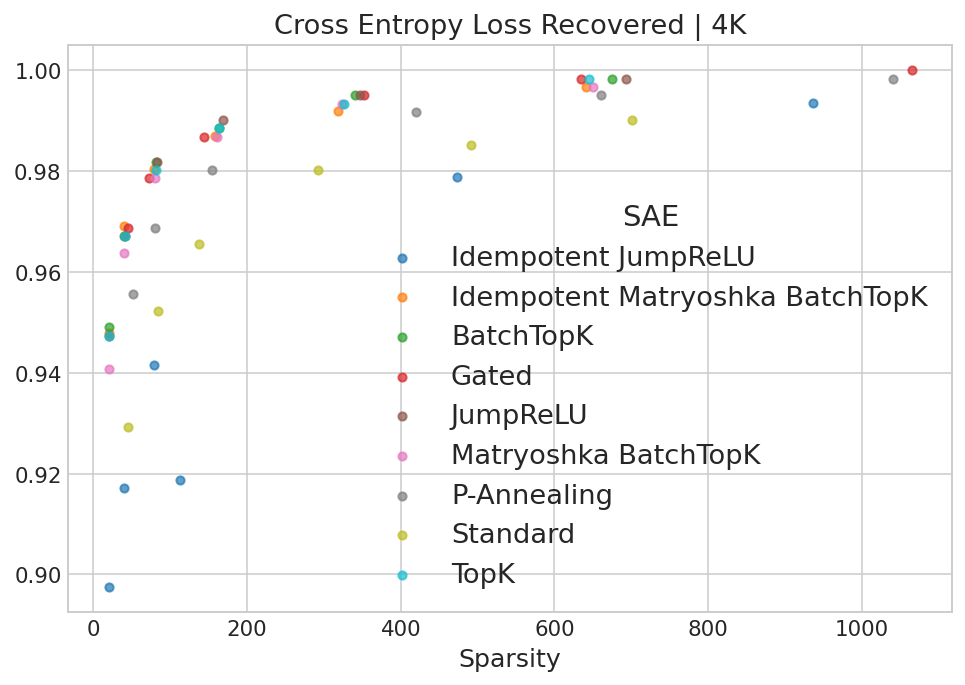

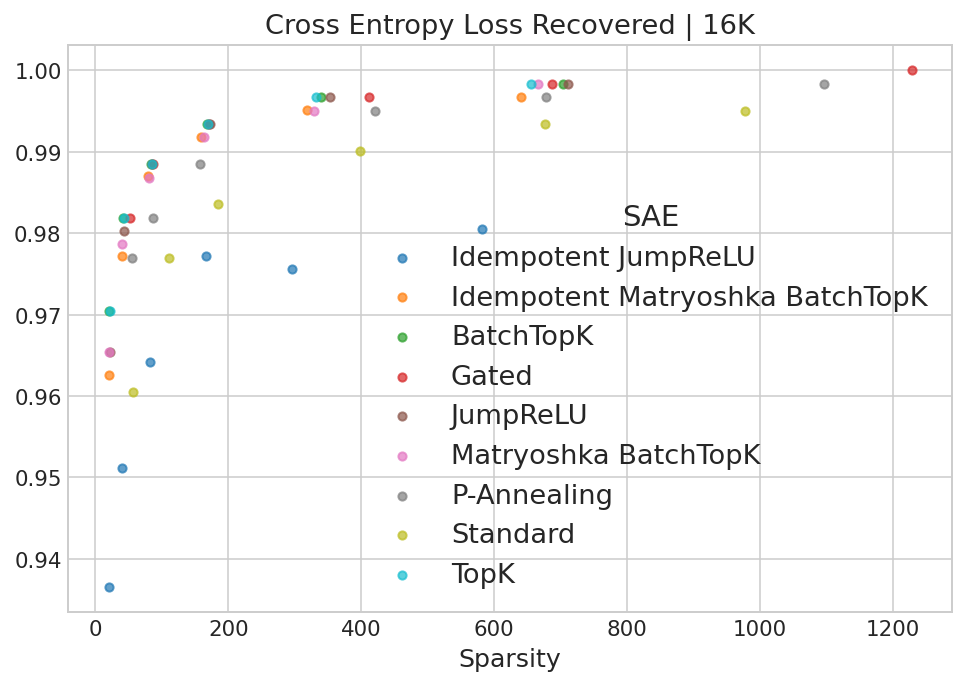

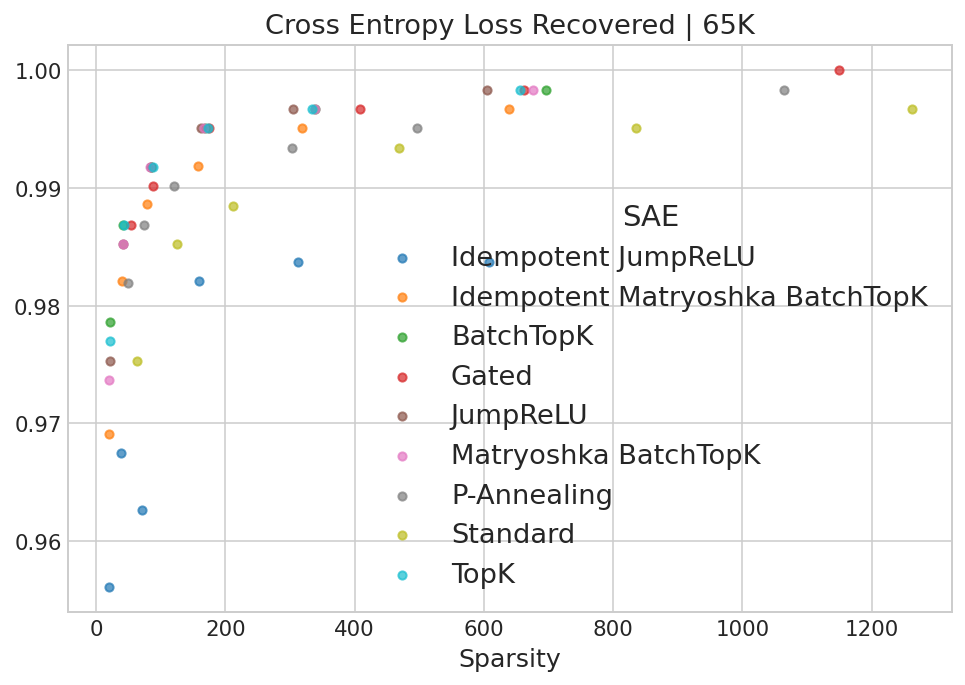

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")

pretty_sae = {
    "IdempotentJumpRelu": "Idempotent JumpReLU",
    "IdempotentMatryoshkaBatchTopK": "Idempotent Matryoshka BatchTopK",
    "batch_topk": "BatchTopK",
    "gated": "Gated",
    "jumprelu": "JumpReLU",
    "matryoshka_batch_topk": "Matryoshka BatchTopK",
    "p-anneal": "P-Annealing",
    "standard": "Standard",
    "topk": "TopK",
}

all_classes = sorted(df_plot["saeClass"].dropna().unique())
# Consistent colors across all dSae plots
cmap = plt.get_cmap("tab10", max(len(all_classes), 1))
class_to_color = {cls: cmap(i) for i, cls in enumerate(all_classes)}

# Optional: log-scale often helps for wide l0 ranges
use_log_x = df_plot["l0"].max() / max(df_plot["l0"].min(), 1e-12) > 100

for d in sorted(df_plot["dSae"].dropna().unique()):
    dfi = df_plot[df_plot["dSae"] == d]

    fig, ax = plt.subplots(figsize=(7, 5), dpi=140)

    for cls in all_classes:
        sub = dfi[dfi["saeClass"] == cls]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["l0"],
            sub["ce_loss_score"],
            s=18,
            alpha=0.7,
            color=class_to_color[cls],
            label=pretty_sae.get(cls, cls),
        )

    ax.set_xlabel("Sparsity" + (" (log scale)" if use_log_x else ""))
    width = {4096: "4K", 16384: "16K", 65536: "65K"}.get(int(d), str(int(d)))
    ax.set_title(f"Cross Entropy Loss Recovered | {width}")

    if use_log_x:
        ax.set_xscale("log")

    ax.legend(title="SAE", loc="best")
    fig.tight_layout()
    plt.show()

In [4]:
# Autointerpretability vs sparsity
AUTO_KEY = "autointerp||autointerp||autointerp_score"

# --- SAEBench aggregated results (saebench_results.json) ---
auto_rows = []
for r in records:
    auto_rows.append(
        {
            "saeClass": r.get("saeClass"),
            "dSae": r.get("dSae"),
            "l0": r.get(X_KEY),
            "autointerp_score": r.get(AUTO_KEY),
        }
    )

df_auto_main = pd.DataFrame(auto_rows)

# --- Idempotent autointerp runs (eval_results/autointerp/Idempotent*.json) ---
auto_idem_rows = []
auto_dir = Path("eval_results/autointerp")
core_dir = Path("eval_results/core")

for p in sorted(auto_dir.glob("Idempotent*.json")):
    with p.open() as f:
        j = json.load(f)

    metrics = (j or {}).get("eval_result_metrics", {})
    auto_score = ((metrics.get("autointerp", {}) or {}).get("autointerp_score"))

    # sparsity (l0) lives in the corresponding core eval result
    l0 = np.nan
    core_p = core_dir / p.name
    if core_p.exists():
        with core_p.open() as f:
            core_j = json.load(f)
        core_metrics = (core_j or {}).get("eval_result_metrics", {})
        l0 = ((core_metrics.get("sparsity", {}) or {}).get("l0"))

    # Prefer d_sae from SAE config if present
    dsae = (((j or {}).get("sae_cfg_dict", {}) or {}).get("d_sae"))
    if dsae is None:
        dsae = _infer_dsae_from_name(p.name)

    auto_idem_rows.append(
        {
            "saeClass": p.stem.split("_")[0],
            "dSae": dsae,
            "l0": l0,
            "autointerp_score": auto_score,
        }
    )

df_auto = pd.concat([df_auto_main, pd.DataFrame(auto_idem_rows)], ignore_index=True)

df_auto["l0"] = pd.to_numeric(df_auto["l0"], errors="coerce")
df_auto["autointerp_score"] = pd.to_numeric(df_auto["autointerp_score"], errors="coerce")
df_auto["dSae"] = pd.to_numeric(df_auto["dSae"], errors="coerce")

df_auto_plot = df_auto.dropna(subset=["l0", "autointerp_score", "dSae"]).copy()

df_auto_plot.shape, df_auto_plot[["l0", "autointerp_score"]].describe()

((162, 4),
                 l0  autointerp_score
 count   162.000000        162.000000
 mean    279.273174          0.831016
 std     297.425929          0.038935
 min      19.433346          0.714429
 25%      52.742581          0.804654
 50%     159.515617          0.833333
 75%     410.581993          0.864196
 max    1262.171875          0.889503)

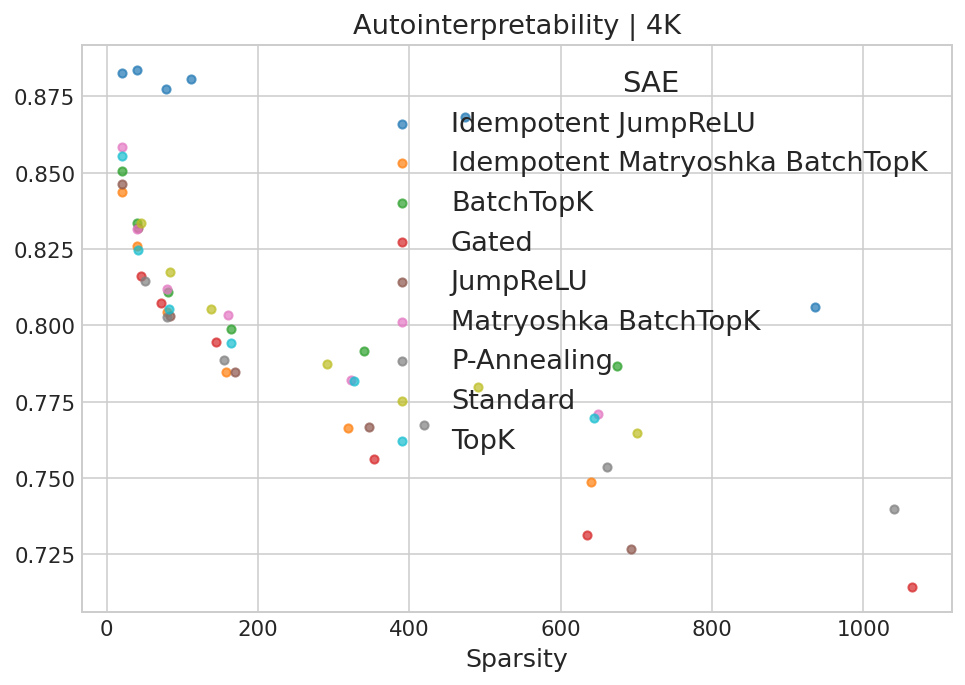

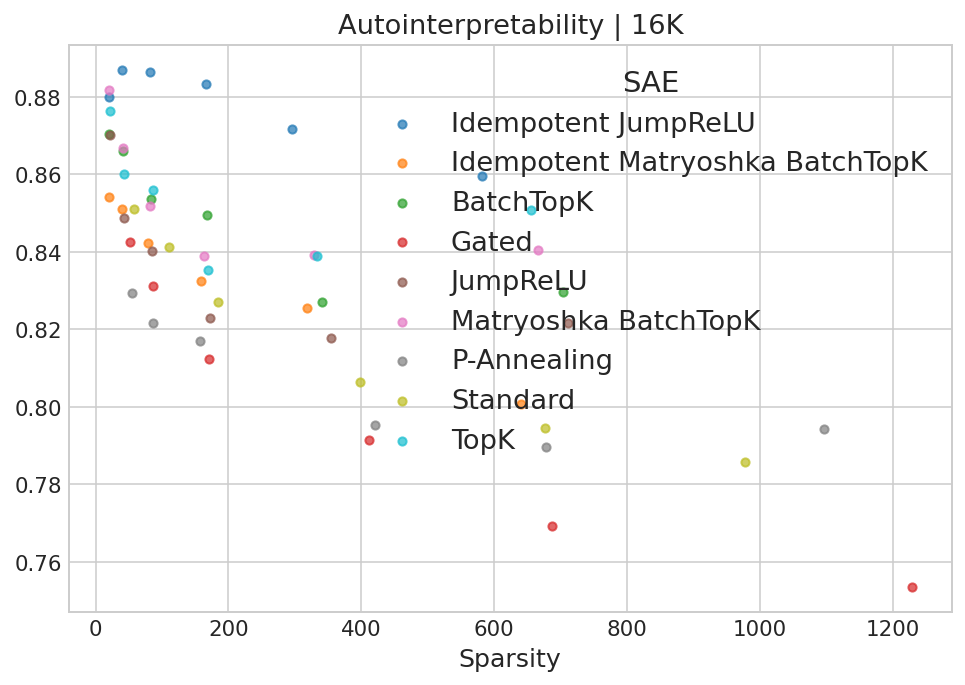

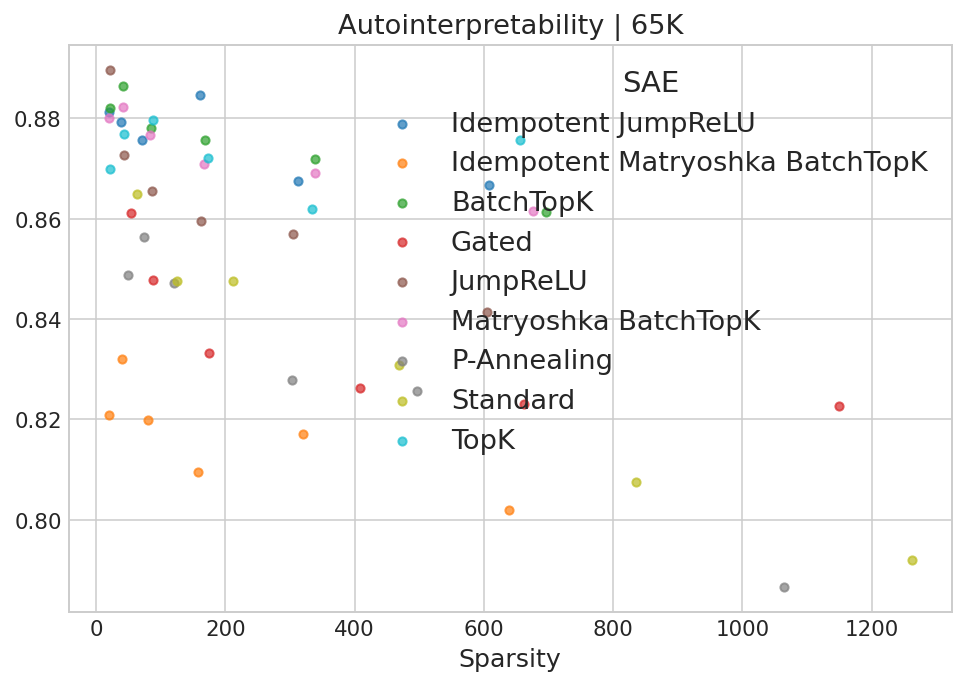

In [5]:
# Plot autointerpretability vs sparsity (one per width, colored by SAE)
plt.style.use("seaborn-v0_8-whitegrid")

all_classes_auto = sorted(df_auto_plot["saeClass"].dropna().unique())

# Use same pretty-name mapping from above plot if available
pretty_sae = globals().get("pretty_sae", {})

cmap = plt.get_cmap("tab10", max(len(all_classes_auto), 1))
class_to_color = {cls: cmap(i) for i, cls in enumerate(all_classes_auto)}

use_log_x = df_auto_plot["l0"].max() / max(df_auto_plot["l0"].min(), 1e-12) > 100

for d in sorted(df_auto_plot["dSae"].dropna().unique()):
    dfi = df_auto_plot[df_auto_plot["dSae"] == d]

    fig, ax = plt.subplots(figsize=(7, 5), dpi=140)

    for cls in all_classes_auto:
        sub = dfi[dfi["saeClass"] == cls]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["l0"],
            sub["autointerp_score"],
            s=18,
            alpha=0.7,
            color=class_to_color[cls],
            label=pretty_sae.get(cls, cls),
        )

    ax.set_xlabel("Sparsity" + (" (log scale)" if use_log_x else ""))
    width = {4096: "4K", 16384: "16K", 65536: "65K"}.get(int(d), str(int(d)))
    ax.set_title(f"Autointerpretability | {width}")

    if use_log_x:
        ax.set_xscale("log")

    ax.legend(title="SAE", loc="best")
    fig.tight_layout()
    plt.show()

In [6]:
# Absorption (first letter) vs sparsity
ABS_FRAC_KEY = "absorption_first_letter||mean||mean_absorption_fraction_score"

# --- SAEBench aggregated results (saebench_results.json) ---
abs_rows = []
for r in records:
    abs_rows.append(
        {
            "saeClass": r.get("saeClass"),
            "dSae": r.get("dSae"),
            "l0": r.get(X_KEY),
            "mean_absorption_fraction_score": r.get(ABS_FRAC_KEY),
        }
    )

df_abs_main = pd.DataFrame(abs_rows)

# --- Idempotent absorption runs (eval_results/absorption/Idempotent*.json) ---
abs_idem_rows = []
abs_dir = Path("eval_results/absorption")
core_dir = Path("eval_results/core")

for p in sorted(abs_dir.glob("Idempotent*.json")):
    with p.open() as f:
        j = json.load(f)

    metrics = (j or {}).get("eval_result_metrics", {})
    mean_metrics = metrics.get("mean", {}) or {}
    mean_frac = mean_metrics.get("mean_absorption_fraction_score")

    # sparsity (l0) lives in the corresponding core eval result
    l0 = np.nan
    core_p = core_dir / p.name
    if core_p.exists():
        with core_p.open() as f:
            core_j = json.load(f)
        core_metrics = (core_j or {}).get("eval_result_metrics", {})
        l0 = ((core_metrics.get("sparsity", {}) or {}).get("l0"))

    # Prefer d_sae from SAE config if present
    dsae = (((j or {}).get("sae_cfg_dict", {}) or {}).get("d_sae"))
    if dsae is None:
        dsae = _infer_dsae_from_name(p.name)

    abs_idem_rows.append(
        {
            "saeClass": p.stem.split("_")[0],
            "dSae": dsae,
            "l0": l0,
            "mean_absorption_fraction_score": mean_frac,
        }
    )

df_abs = pd.concat([df_abs_main, pd.DataFrame(abs_idem_rows)], ignore_index=True)

df_abs["l0"] = pd.to_numeric(df_abs["l0"], errors="coerce")
df_abs["mean_absorption_fraction_score"] = pd.to_numeric(
    df_abs["mean_absorption_fraction_score"], errors="coerce"
)
df_abs["dSae"] = pd.to_numeric(df_abs["dSae"], errors="coerce")

# Plotting convention: 1 - absorption score
# (So higher is "less absorption" / worse absorption, depending on interpretation.)
df_abs["one_minus_absorption"] = 1.0 - df_abs["mean_absorption_fraction_score"]

df_abs_plot = df_abs.dropna(
    subset=["l0", "one_minus_absorption", "dSae"]
).copy()

df_abs_plot.shape, df_abs_plot[["l0", "one_minus_absorption"]].describe()

((162, 5),
                 l0  one_minus_absorption
 count   162.000000            162.000000
 mean    279.273174              0.826123
 std     297.425929              0.164733
 min      19.433346              0.411367
 25%      52.742581              0.721928
 50%     159.515617              0.887206
 75%     410.581993              0.952989
 max    1262.171875              0.996733)

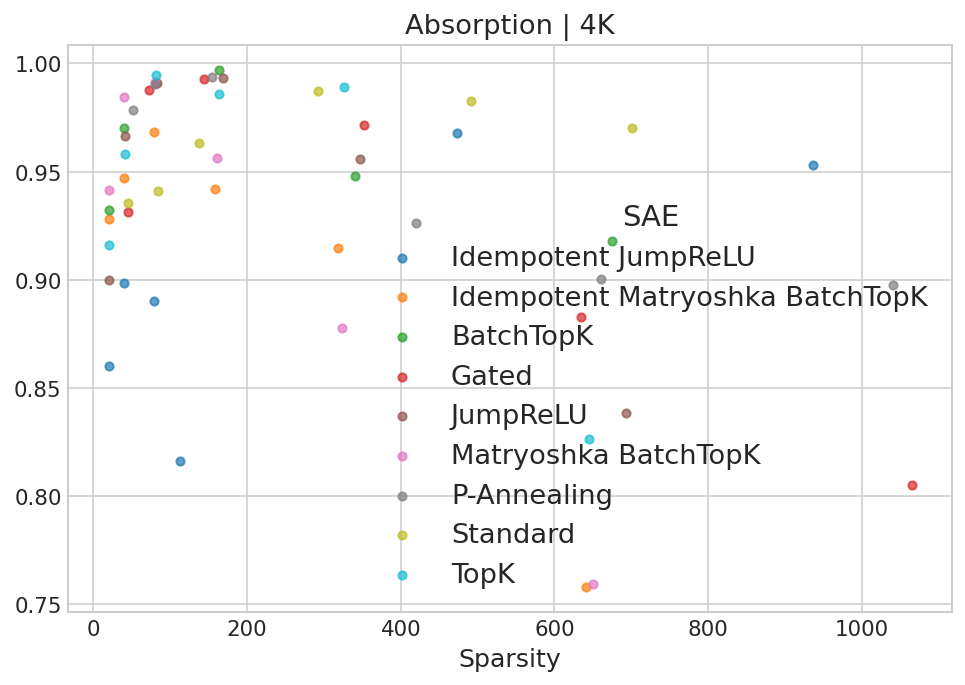

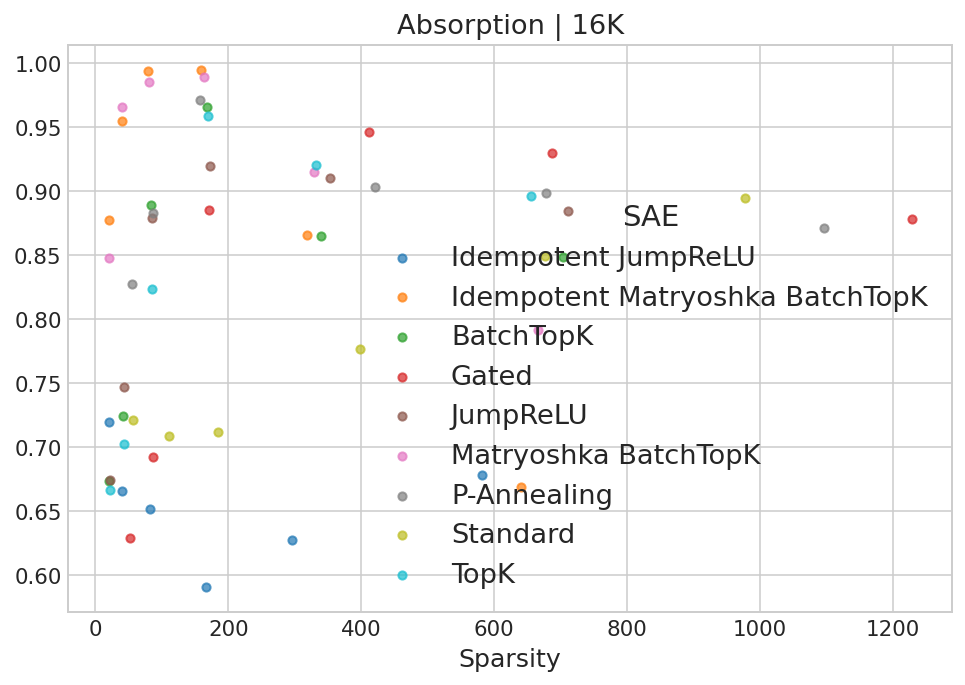

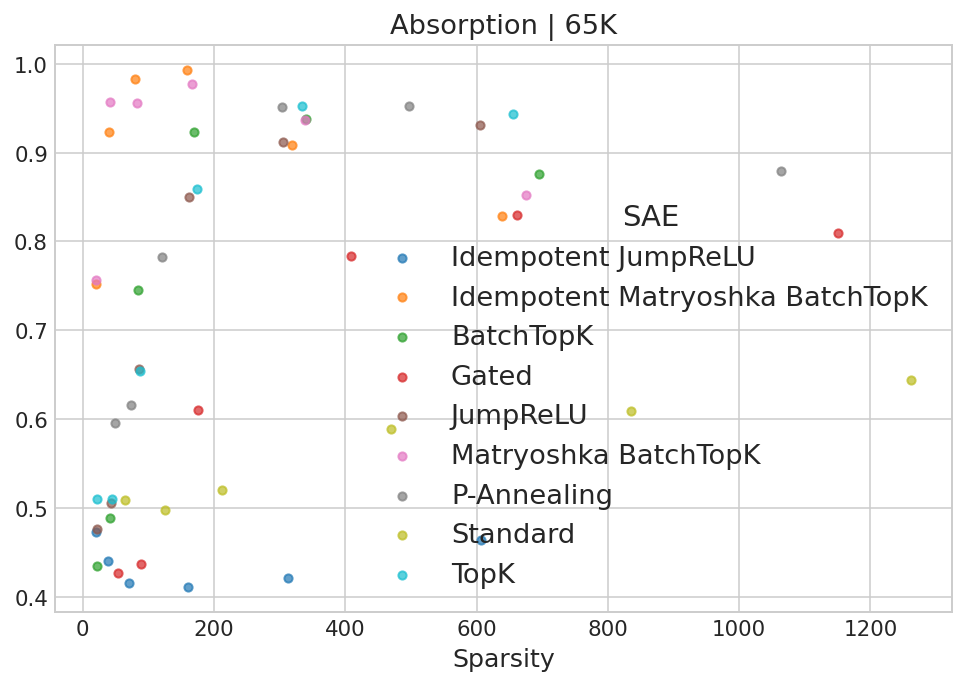

In [7]:
# Plot absorption (first letter) vs sparsity (one per width, colored by SAE)
plt.style.use("seaborn-v0_8-whitegrid")

all_classes_abs = sorted(df_abs_plot["saeClass"].dropna().unique())
pretty_sae = globals().get("pretty_sae", {})

cmap = plt.get_cmap("tab10", max(len(all_classes_abs), 1))
class_to_color = {cls: cmap(i) for i, cls in enumerate(all_classes_abs)}

use_log_x = df_abs_plot["l0"].max() / max(df_abs_plot["l0"].min(), 1e-12) > 100

for d in sorted(df_abs_plot["dSae"].dropna().unique()):
    dfi = df_abs_plot[df_abs_plot["dSae"] == d]

    fig, ax = plt.subplots(figsize=(7, 5), dpi=140)

    for cls in all_classes_abs:
        sub = dfi[dfi["saeClass"] == cls]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["l0"],
            sub["one_minus_absorption"],
            s=18,
            alpha=0.7,
            color=class_to_color[cls],
            label=pretty_sae.get(cls, cls),
        )

    ax.set_xlabel("Sparsity" + (" (log scale)" if use_log_x else ""))
    width = {4096: "4K", 16384: "16K", 65536: "65K"}.get(int(d), str(int(d)))
    ax.set_title(f"Absorption | {width}")

    if use_log_x:
        ax.set_xscale("log")

    ax.legend(title="SAE", loc="best")
    fig.tight_layout()
    plt.show()

In [8]:
# SCR vs sparsity
SCR_KEY = "scr||scr_metrics||scr_metric_threshold_20"

# --- SAEBench aggregated results (saebench_results.json) ---
scr_rows = []
for r in records:
    scr_rows.append(
        {
            "saeClass": r.get("saeClass"),
            "dSae": r.get("dSae"),
            "l0": r.get(X_KEY),
            "scr_metric_threshold_20": r.get(SCR_KEY),
        }
    )

df_scr_main = pd.DataFrame(scr_rows)

# --- Idempotent SCR runs (eval_results/scr/Idempotent*.json) ---
scr_idem_rows = []
scr_dir = Path("eval_results/scr")
core_dir = Path("eval_results/core")

for p in sorted(scr_dir.glob("Idempotent*.json")):
    with p.open() as f:
        j = json.load(f)

    metrics = (j or {}).get("eval_result_metrics", {})
    scr_metrics = metrics.get("scr_metrics", {}) or {}
    scr_20 = scr_metrics.get("scr_metric_threshold_20")

    # sparsity (l0) lives in the corresponding core eval result
    l0 = np.nan
    core_p = core_dir / p.name
    if core_p.exists():
        with core_p.open() as f:
            core_j = json.load(f)
        core_metrics = (core_j or {}).get("eval_result_metrics", {})
        l0 = ((core_metrics.get("sparsity", {}) or {}).get("l0"))

    # Prefer d_sae from SAE config if present
    dsae = (((j or {}).get("sae_cfg_dict", {}) or {}).get("d_sae"))
    if dsae is None:
        dsae = _infer_dsae_from_name(p.name)

    scr_idem_rows.append(
        {
            "saeClass": p.stem.split("_")[0],
            "dSae": dsae,
            "l0": l0,
            "scr_metric_threshold_20": scr_20,
        }
    )

df_scr = pd.concat([df_scr_main, pd.DataFrame(scr_idem_rows)], ignore_index=True)

df_scr["l0"] = pd.to_numeric(df_scr["l0"], errors="coerce")
df_scr["scr_metric_threshold_20"] = pd.to_numeric(
    df_scr["scr_metric_threshold_20"], errors="coerce"
)
df_scr["dSae"] = pd.to_numeric(df_scr["dSae"], errors="coerce")

df_scr_plot = df_scr.dropna(subset=["l0", "scr_metric_threshold_20", "dSae"]).copy()

df_scr_plot.shape, df_scr_plot[["l0", "scr_metric_threshold_20"]].describe()

((162, 4),
                 l0  scr_metric_threshold_20
 count   162.000000               162.000000
 mean    279.273174                 0.248309
 std     297.425929                 0.107251
 min      19.433346                -0.163968
 25%      52.742581                 0.219091
 50%     159.515617                 0.273120
 75%     410.581993                 0.316466
 max    1262.171875                 0.475110)

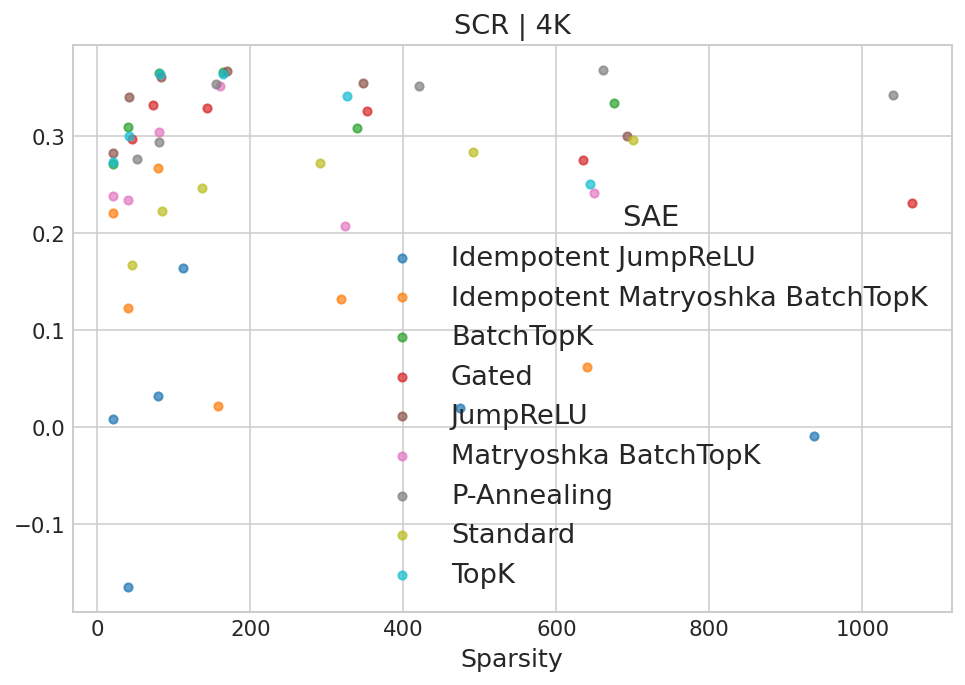

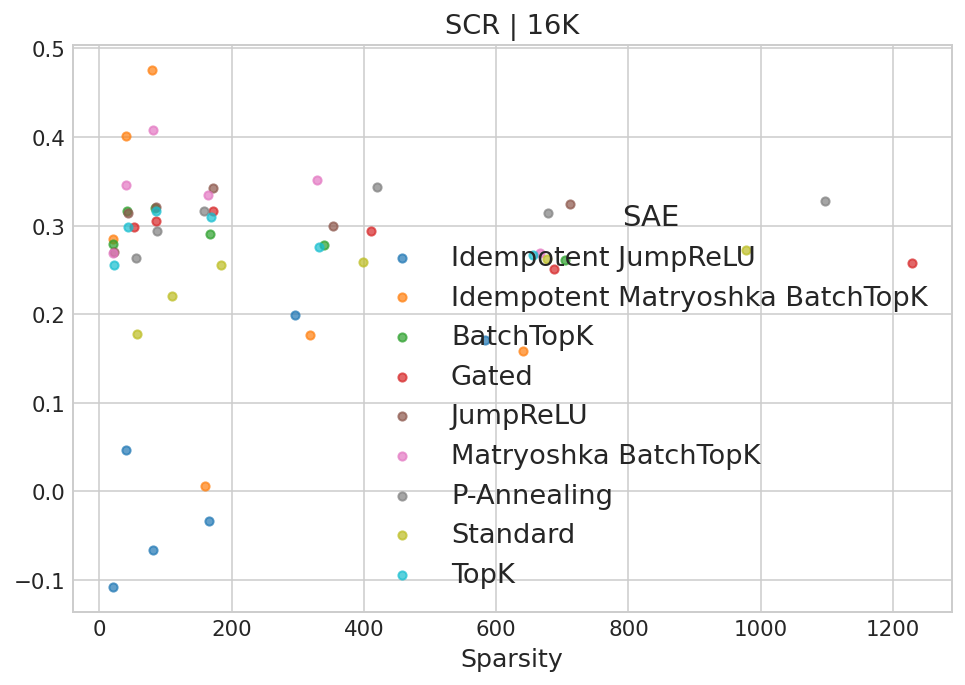

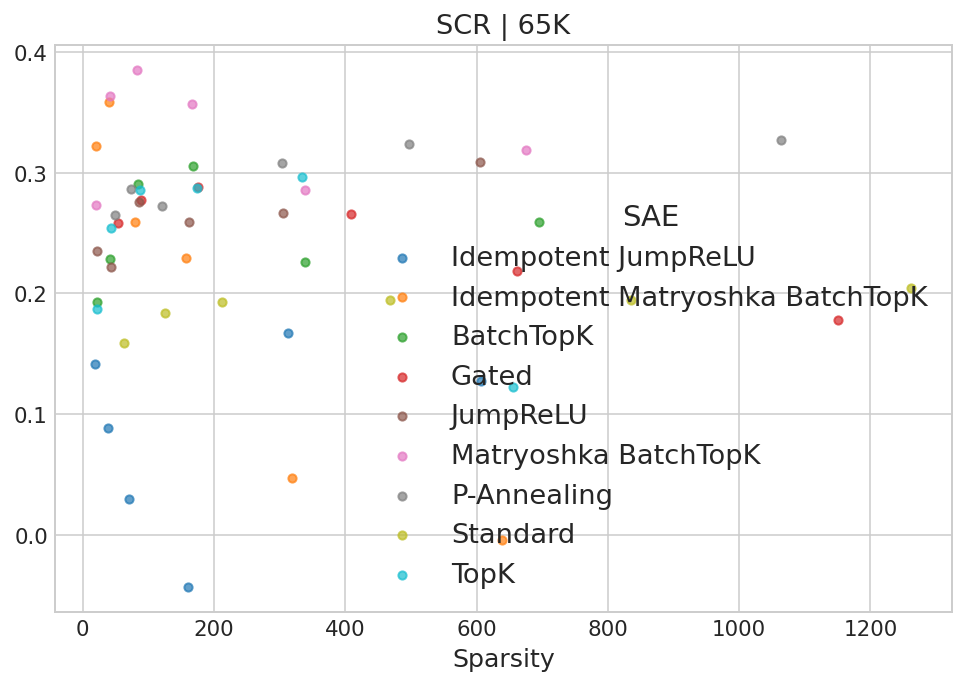

In [9]:
# Plot SCR vs sparsity (one per width, colored by SAE)
plt.style.use("seaborn-v0_8-whitegrid")

all_classes_scr = sorted(df_scr_plot["saeClass"].dropna().unique())
pretty_sae = globals().get("pretty_sae", {})

cmap = plt.get_cmap("tab10", max(len(all_classes_scr), 1))
class_to_color = {cls: cmap(i) for i, cls in enumerate(all_classes_scr)}

use_log_x = df_scr_plot["l0"].max() / max(df_scr_plot["l0"].min(), 1e-12) > 100

for d in sorted(df_scr_plot["dSae"].dropna().unique()):
    dfi = df_scr_plot[df_scr_plot["dSae"] == d]

    fig, ax = plt.subplots(figsize=(7, 5), dpi=140)

    for cls in all_classes_scr:
        sub = dfi[dfi["saeClass"] == cls]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["l0"],
            sub["scr_metric_threshold_20"],
            s=18,
            alpha=0.7,
            color=class_to_color[cls],
            label=pretty_sae.get(cls, cls),
        )

    ax.set_xlabel("Sparsity" + (" (log scale)" if use_log_x else ""))
    width = {4096: "4K", 16384: "16K", 65536: "65K"}.get(int(d), str(int(d)))
    ax.set_title(f"SCR | {width}")

    if use_log_x:
        ax.set_xscale("log")

    ax.legend(title="SAE", loc="best")
    fig.tight_layout()
    plt.show()

In [10]:
# TPP vs sparsity
TPP_KEY = "tpp||tpp_metrics||tpp_threshold_20_total_metric"

# --- SAEBench aggregated results (saebench_results.json) ---
tpp_rows = []
for r in records:
    tpp_rows.append(
        {
            "saeClass": r.get("saeClass"),
            "dSae": r.get("dSae"),
            "l0": r.get(X_KEY),
            "tpp_threshold_20_total_metric": r.get(TPP_KEY),
        }
    )

df_tpp_main = pd.DataFrame(tpp_rows)

# --- Idempotent TPP runs (eval_results/tpp/Idempotent*.json) ---
tpp_idem_rows = []
tpp_dir = Path("eval_results/tpp")
core_dir = Path("eval_results/core")

for p in sorted(tpp_dir.glob("Idempotent*.json")):
    with p.open() as f:
        j = json.load(f)

    metrics = (j or {}).get("eval_result_metrics", {})
    tpp_metrics = metrics.get("tpp_metrics", {}) or {}
    tpp_20 = tpp_metrics.get("tpp_threshold_20_total_metric")

    # sparsity (l0) lives in the corresponding core eval result
    l0 = np.nan
    core_p = core_dir / p.name
    if core_p.exists():
        with core_p.open() as f:
            core_j = json.load(f)
        core_metrics = (core_j or {}).get("eval_result_metrics", {})
        l0 = ((core_metrics.get("sparsity", {}) or {}).get("l0"))

    # Prefer d_sae from SAE config if present
    dsae = (((j or {}).get("sae_cfg_dict", {}) or {}).get("d_sae"))
    if dsae is None:
        dsae = _infer_dsae_from_name(p.name)

    tpp_idem_rows.append(
        {
            "saeClass": p.stem.split("_")[0],
            "dSae": dsae,
            "l0": l0,
            "tpp_threshold_20_total_metric": tpp_20,
        }
    )

df_tpp = pd.concat([df_tpp_main, pd.DataFrame(tpp_idem_rows)], ignore_index=True)

df_tpp["l0"] = pd.to_numeric(df_tpp["l0"], errors="coerce")
df_tpp["tpp_threshold_20_total_metric"] = pd.to_numeric(
    df_tpp["tpp_threshold_20_total_metric"], errors="coerce"
)
df_tpp["dSae"] = pd.to_numeric(df_tpp["dSae"], errors="coerce")

df_tpp_plot = df_tpp.dropna(
    subset=["l0", "tpp_threshold_20_total_metric", "dSae"]
).copy()

df_tpp_plot.shape, df_tpp_plot[["l0", "tpp_threshold_20_total_metric"]].describe()

((162, 4),
                 l0  tpp_threshold_20_total_metric
 count   162.000000                     162.000000
 mean    279.273174                       0.120668
 std     297.425929                       0.108960
 min      19.433346                       0.009000
 25%      52.742581                       0.033531
 50%     159.515617                       0.068838
 75%     410.581993                       0.182613
 max    1262.171875                       0.367625)

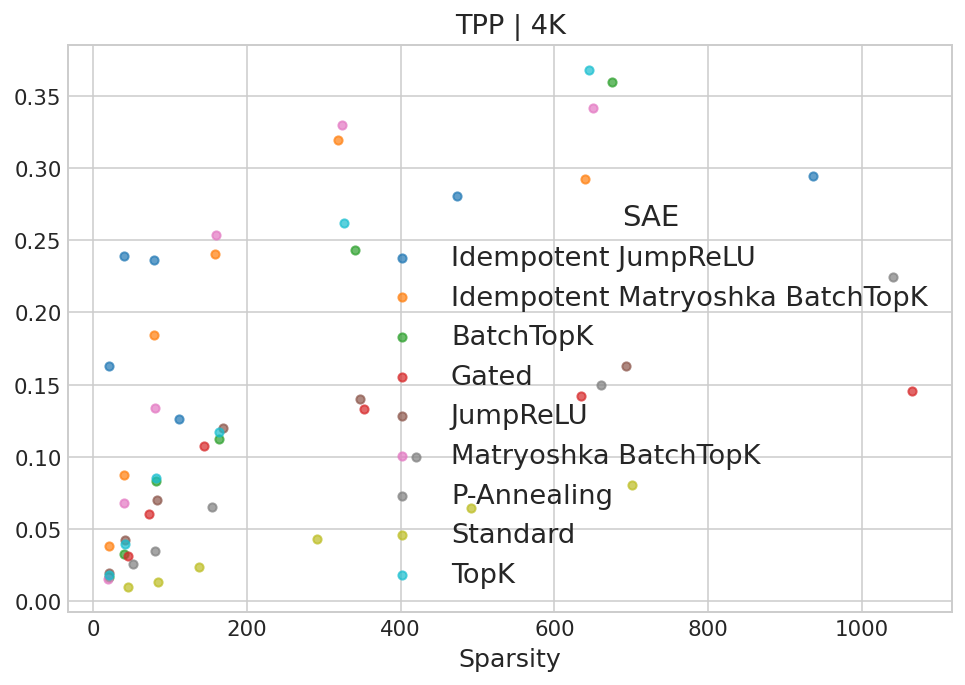

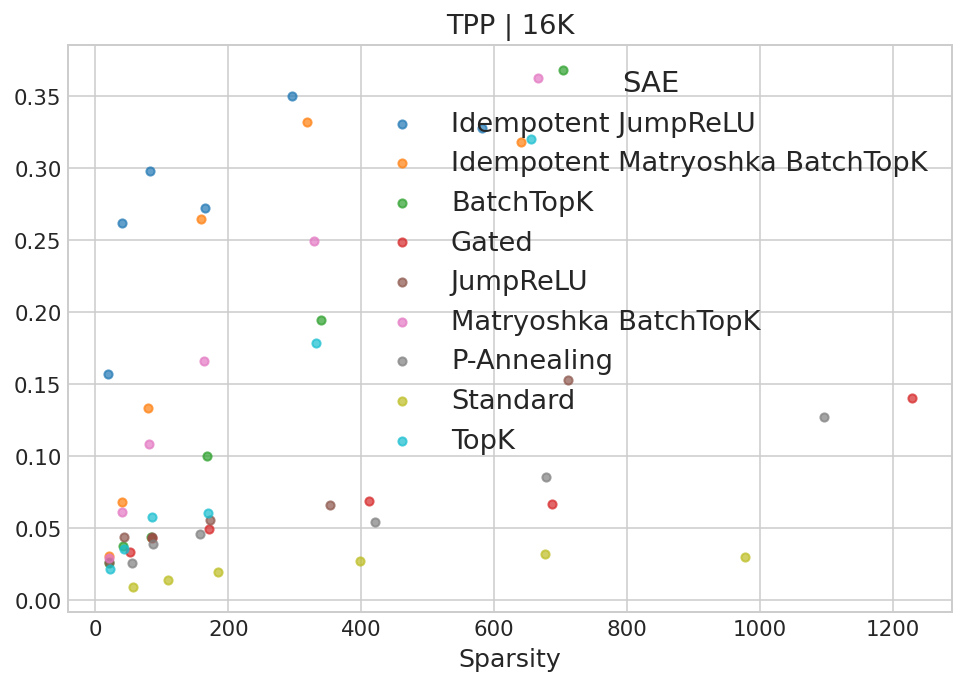

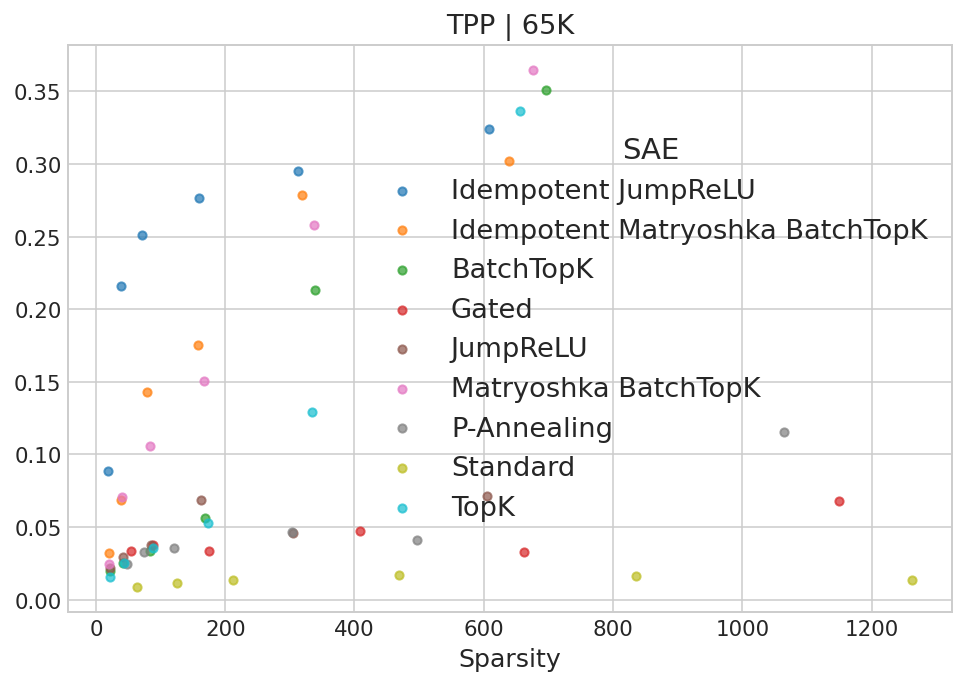

In [11]:
# Plot TPP vs sparsity (one per width, colored by SAE)
plt.style.use("seaborn-v0_8-whitegrid")

all_classes_tpp = sorted(df_tpp_plot["saeClass"].dropna().unique())
pretty_sae = globals().get("pretty_sae", {})

cmap = plt.get_cmap("tab10", max(len(all_classes_tpp), 1))
class_to_color = {cls: cmap(i) for i, cls in enumerate(all_classes_tpp)}

use_log_x = df_tpp_plot["l0"].max() / max(df_tpp_plot["l0"].min(), 1e-12) > 100

for d in sorted(df_tpp_plot["dSae"].dropna().unique()):
    dfi = df_tpp_plot[df_tpp_plot["dSae"] == d]

    fig, ax = plt.subplots(figsize=(7, 5), dpi=140)

    for cls in all_classes_tpp:
        sub = dfi[dfi["saeClass"] == cls]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["l0"],
            sub["tpp_threshold_20_total_metric"],
            s=18,
            alpha=0.7,
            color=class_to_color[cls],
            label=pretty_sae.get(cls, cls),
        )

    ax.set_xlabel("Sparsity" + (" (log scale)" if use_log_x else ""))
    width = {4096: "4K", 16384: "16K", 65536: "65K"}.get(int(d), str(int(d)))
    ax.set_title(f"TPP | {width}")

    if use_log_x:
        ax.set_xscale("log")

    ax.legend(title="SAE", loc="best")
    fig.tight_layout()
    plt.show()

In [12]:
# Unlearning vs sparsity
UNLEARN_KEY = "unlearning||unlearning||unlearning_score"

# --- SAEBench aggregated results (saebench_results.json) ---
un_rows = []
for r in records:
    un_rows.append(
        {
            "saeClass": r.get("saeClass"),
            "dSae": r.get("dSae"),
            "l0": r.get(X_KEY),
            "unlearning_score": r.get(UNLEARN_KEY),
        }
    )

df_un_main = pd.DataFrame(un_rows)

# --- Idempotent unlearning runs (eval_results/unlearning/Idempotent*.json) ---
un_idem_rows = []
un_dir = Path("eval_results/unlearning")
core_dir = Path("eval_results/core")

for p in sorted(un_dir.glob("Idempotent*.json")):
    with p.open() as f:
        j = json.load(f)

    metrics = (j or {}).get("eval_result_metrics", {})
    unlearning_metrics = metrics.get("unlearning", {}) or {}
    un_score = unlearning_metrics.get("unlearning_score")

    # sparsity (l0) lives in the corresponding core eval result
    l0 = np.nan
    core_p = core_dir / p.name
    if core_p.exists():
        with core_p.open() as f:
            core_j = json.load(f)
        core_metrics = (core_j or {}).get("eval_result_metrics", {})
        l0 = ((core_metrics.get("sparsity", {}) or {}).get("l0"))

    # Prefer d_sae from SAE config if present
    dsae = (((j or {}).get("sae_cfg_dict", {}) or {}).get("d_sae"))
    if dsae is None:
        dsae = _infer_dsae_from_name(p.name)

    un_idem_rows.append(
        {
            "saeClass": p.stem.split("_")[0],
            "dSae": dsae,
            "l0": l0,
            "unlearning_score": un_score,
        }
    )

df_un = pd.concat([df_un_main, pd.DataFrame(un_idem_rows)], ignore_index=True)

df_un["l0"] = pd.to_numeric(df_un["l0"], errors="coerce")
df_un["unlearning_score"] = pd.to_numeric(df_un["unlearning_score"], errors="coerce")
df_un["dSae"] = pd.to_numeric(df_un["dSae"], errors="coerce")

df_un_plot = df_un.dropna(subset=["l0", "unlearning_score", "dSae"]).copy()

df_un_plot.shape, df_un_plot[["l0", "unlearning_score"]].describe()

((162, 4),
                 l0  unlearning_score
 count   162.000000        162.000000
 mean    279.273174          0.059702
 std     297.425929          0.044818
 min      19.433346          0.001876
 25%      52.742581          0.024390
 50%     159.515617          0.048781
 75%     410.581993          0.085835
 max    1262.171875          0.202627)

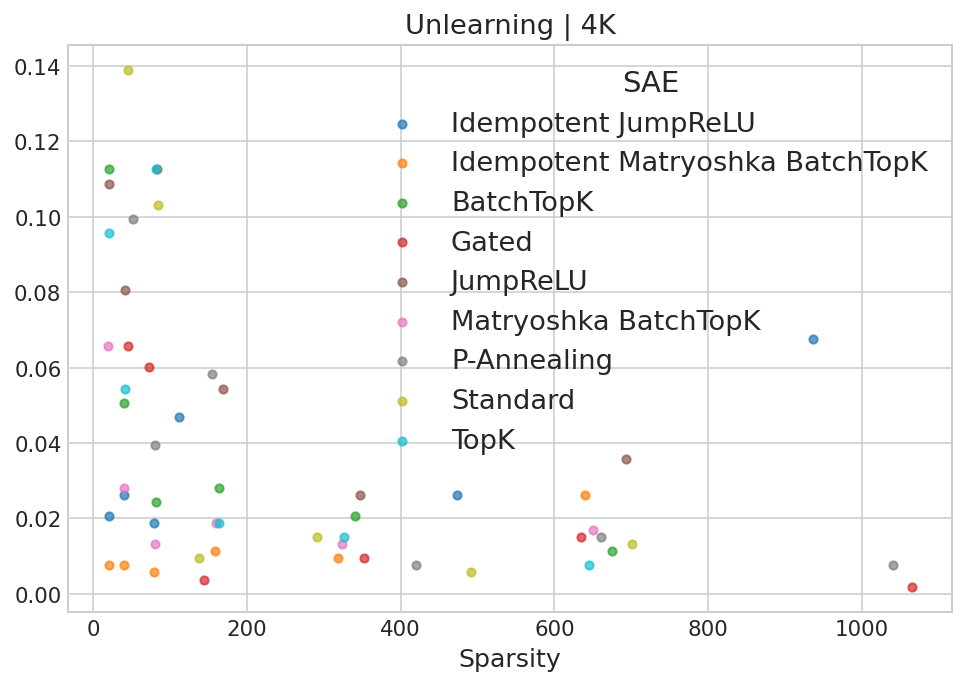

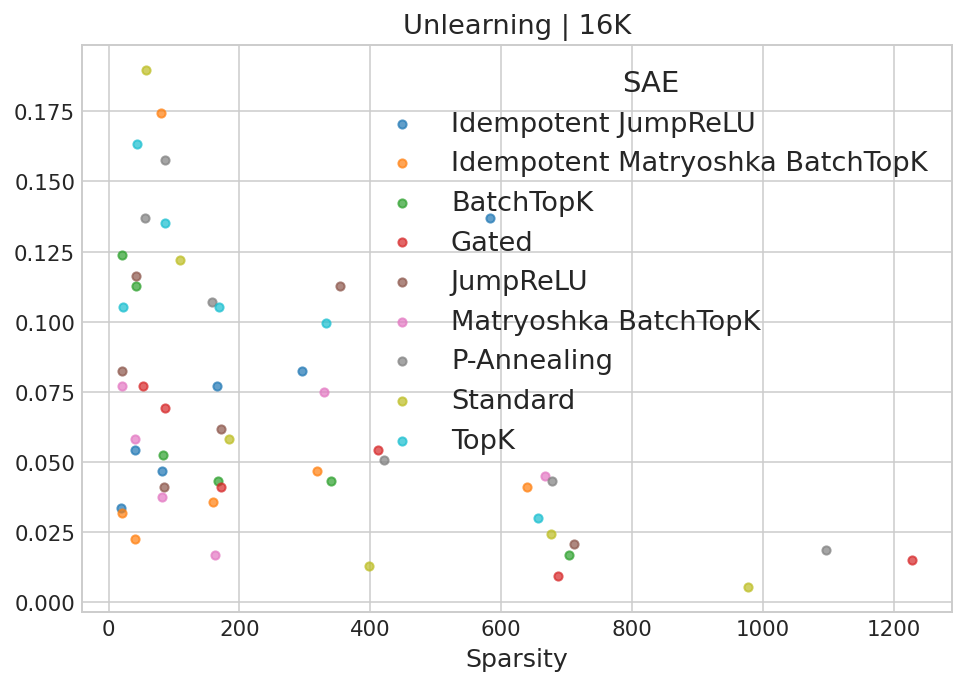

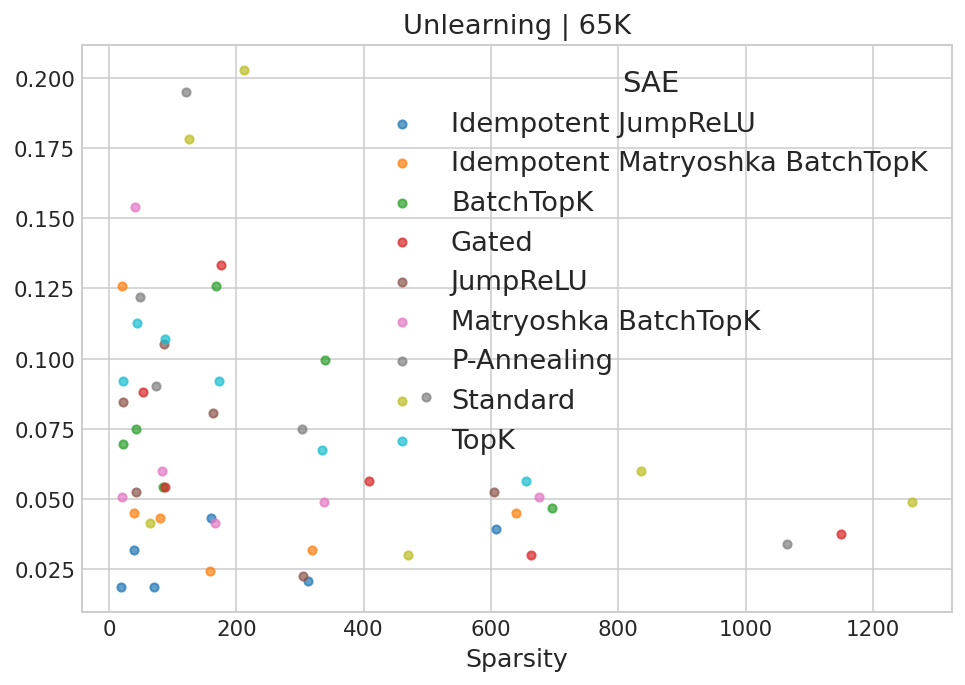

In [13]:
# Plot unlearning score vs sparsity (one per width, colored by SAE)
plt.style.use("seaborn-v0_8-whitegrid")

all_classes_un = sorted(df_un_plot["saeClass"].dropna().unique())
pretty_sae = globals().get("pretty_sae", {})

cmap = plt.get_cmap("tab10", max(len(all_classes_un), 1))
class_to_color = {cls: cmap(i) for i, cls in enumerate(all_classes_un)}

use_log_x = df_un_plot["l0"].max() / max(df_un_plot["l0"].min(), 1e-12) > 100

for d in sorted(df_un_plot["dSae"].dropna().unique()):
    dfi = df_un_plot[df_un_plot["dSae"] == d]

    fig, ax = plt.subplots(figsize=(7, 5), dpi=140)

    for cls in all_classes_un:
        sub = dfi[dfi["saeClass"] == cls]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["l0"],
            sub["unlearning_score"],
            s=18,
            alpha=0.7,
            color=class_to_color[cls],
            label=pretty_sae.get(cls, cls),
        )

    ax.set_xlabel("Sparsity" + (" (log scale)" if use_log_x else ""))
    width = {4096: "4K", 16384: "16K", 65536: "65K"}.get(int(d), str(int(d)))
    ax.set_title(f"Unlearning | {width}")

    if use_log_x:
        ax.set_xscale("log")

    ax.legend(title="SAE", loc="best")
    fig.tight_layout()
    plt.show()

In [14]:
# Sparse probing (SAE top-1 test accuracy) vs sparsity
SPARSE_TOP1_KEY = "sparse_probing||sae||sae_top_1_test_accuracy"

# --- SAEBench aggregated results (saebench_results.json) ---
sp_rows = []
for r in records:
    sp_rows.append(
        {
            "saeClass": r.get("saeClass"),
            "dSae": r.get("dSae"),
            "l0": r.get(X_KEY),
            "sae_top_1_test_accuracy": r.get(SPARSE_TOP1_KEY),
        }
    )

df_sp_main = pd.DataFrame(sp_rows)

# --- Idempotent sparse probing runs (eval_results/sparse_probing/Idempotent*.json) ---
sp_idem_rows = []
sp_dir = Path("eval_results/sparse_probing")
core_dir = Path("eval_results/core")

for p in sorted(sp_dir.glob("Idempotent*.json")):
    with p.open() as f:
        j = json.load(f)

    metrics = (j or {}).get("eval_result_metrics", {})
    sae_metrics = metrics.get("sae", {}) or {}
    top1 = sae_metrics.get("sae_top_1_test_accuracy")

    # sparsity (l0) lives in the corresponding core eval result
    l0 = np.nan
    core_p = core_dir / p.name
    if core_p.exists():
        with core_p.open() as f:
            core_j = json.load(f)
        core_metrics = (core_j or {}).get("eval_result_metrics", {})
        l0 = ((core_metrics.get("sparsity", {}) or {}).get("l0"))

    # Prefer d_sae from SAE config if present
    dsae = (((j or {}).get("sae_cfg_dict", {}) or {}).get("d_sae"))
    if dsae is None:
        dsae = _infer_dsae_from_name(p.name)

    sp_idem_rows.append(
        {
            "saeClass": p.stem.split("_")[0],
            "dSae": dsae,
            "l0": l0,
            "sae_top_1_test_accuracy": top1,
        }
    )

df_sp = pd.concat([df_sp_main, pd.DataFrame(sp_idem_rows)], ignore_index=True)

df_sp["l0"] = pd.to_numeric(df_sp["l0"], errors="coerce")
df_sp["sae_top_1_test_accuracy"] = pd.to_numeric(
    df_sp["sae_top_1_test_accuracy"], errors="coerce"
)
df_sp["dSae"] = pd.to_numeric(df_sp["dSae"], errors="coerce")

df_sp_plot = df_sp.dropna(subset=["l0", "sae_top_1_test_accuracy", "dSae"]).copy()

df_sp_plot.shape, df_sp_plot[["l0", "sae_top_1_test_accuracy"]].describe()

((162, 4),
                 l0  sae_top_1_test_accuracy
 count   162.000000               162.000000
 mean    279.273174                 0.754464
 std     297.425929                 0.029961
 min      19.433346                 0.669631
 25%      52.742581                 0.736802
 50%     159.515617                 0.756462
 75%     410.581993                 0.775380
 max    1262.171875                 0.824350)

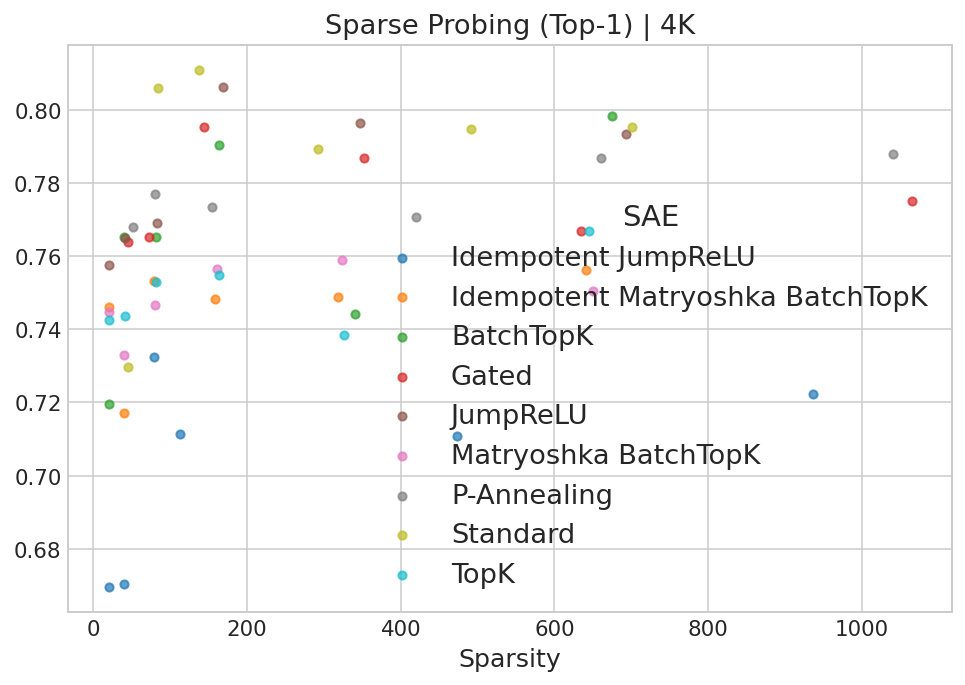

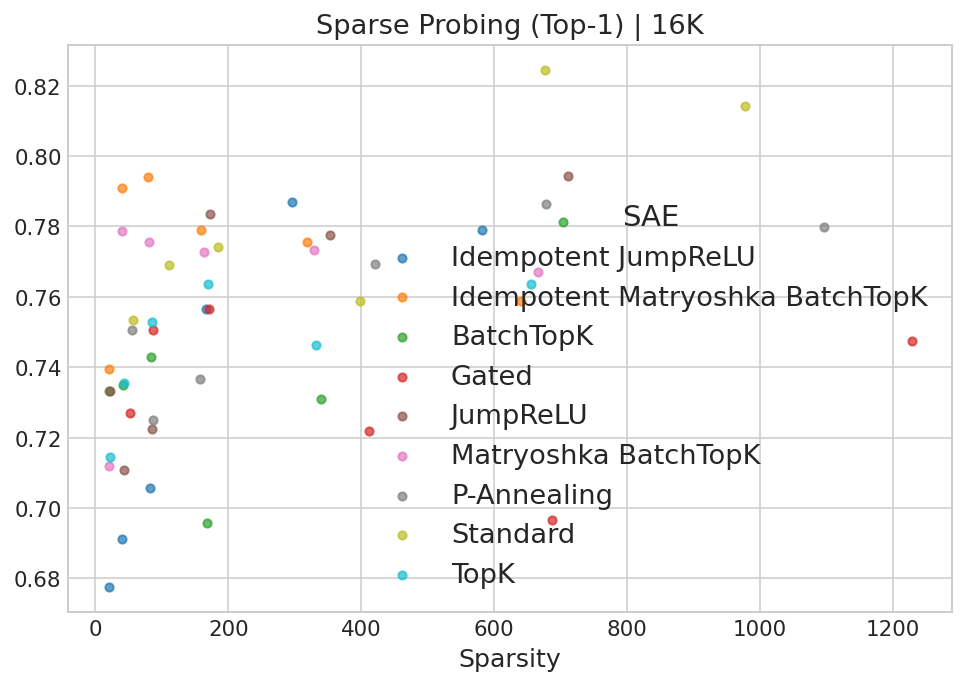

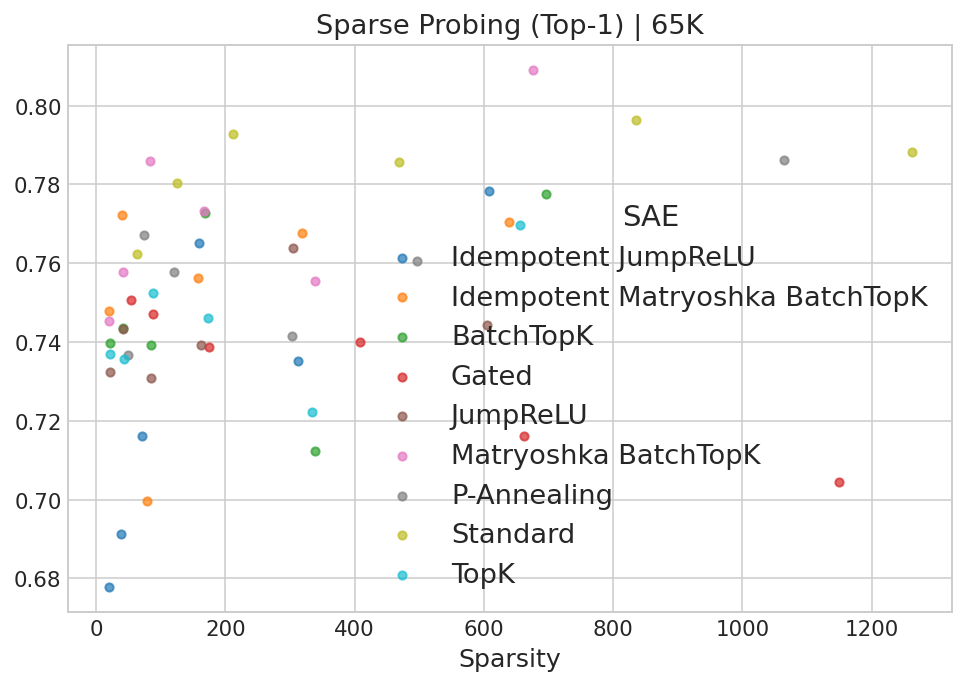

In [15]:
# Plot sparse probing (SAE top-1 accuracy) vs sparsity (one per width, colored by SAE)
plt.style.use("seaborn-v0_8-whitegrid")

all_classes_sp = sorted(df_sp_plot["saeClass"].dropna().unique())
pretty_sae = globals().get("pretty_sae", {})

cmap = plt.get_cmap("tab10", max(len(all_classes_sp), 1))
class_to_color = {cls: cmap(i) for i, cls in enumerate(all_classes_sp)}

use_log_x = df_sp_plot["l0"].max() / max(df_sp_plot["l0"].min(), 1e-12) > 100

for d in sorted(df_sp_plot["dSae"].dropna().unique()):
    dfi = df_sp_plot[df_sp_plot["dSae"] == d]

    fig, ax = plt.subplots(figsize=(7, 5), dpi=140)

    for cls in all_classes_sp:
        sub = dfi[dfi["saeClass"] == cls]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["l0"],
            sub["sae_top_1_test_accuracy"],
            s=18,
            alpha=0.7,
            color=class_to_color[cls],
            label=pretty_sae.get(cls, cls),
        )

    ax.set_xlabel("Sparsity" + (" (log scale)" if use_log_x else ""))
    width = {4096: "4K", 16384: "16K", 65536: "65K"}.get(int(d), str(int(d)))
    ax.set_title(f"Sparse Probing (Top-1) | {width}")

    if use_log_x:
        ax.set_xscale("log")

    ax.legend(title="SAE", loc="best")
    fig.tight_layout()
    plt.show()

In [16]:
# Ravel disentanglement vs sparsity
RAVEL_KEY = "ravel||ravel||disentanglement_score"

# --- SAEBench aggregated results (saebench_results.json) ---
rv_rows = []
for r in records:
    rv_rows.append(
        {
            "saeClass": r.get("saeClass"),
            "dSae": r.get("dSae"),
            "l0": r.get(X_KEY),
            "disentanglement_score": r.get(RAVEL_KEY),
        }
    )

df_rv_main = pd.DataFrame(rv_rows)

# --- Idempotent ravel runs (eval_results/ravel/Idempotent*.json) ---
rv_idem_rows = []
rv_dir = Path("eval_results/ravel")
core_dir = Path("eval_results/core")

for p in sorted(rv_dir.glob("Idempotent*.json")):
    with p.open() as f:
        j = json.load(f)

    metrics = (j or {}).get("eval_result_metrics", {})
    ravel_metrics = metrics.get("ravel", {}) or {}
    disent = ravel_metrics.get("disentanglement_score")

    # sparsity (l0) lives in the corresponding core eval result
    l0 = np.nan
    core_p = core_dir / p.name
    if core_p.exists():
        with core_p.open() as f:
            core_j = json.load(f)
        core_metrics = (core_j or {}).get("eval_result_metrics", {})
        l0 = ((core_metrics.get("sparsity", {}) or {}).get("l0"))

    # Prefer d_sae from SAE config if present
    dsae = (((j or {}).get("sae_cfg_dict", {}) or {}).get("d_sae"))
    if dsae is None:
        dsae = _infer_dsae_from_name(p.name)

    rv_idem_rows.append(
        {
            "saeClass": p.stem.split("_")[0],
            "dSae": dsae,
            "l0": l0,
            "disentanglement_score": disent,
        }
    )

df_rv = pd.concat([df_rv_main, pd.DataFrame(rv_idem_rows)], ignore_index=True)

df_rv["l0"] = pd.to_numeric(df_rv["l0"], errors="coerce")
df_rv["disentanglement_score"] = pd.to_numeric(
    df_rv["disentanglement_score"], errors="coerce"
)
df_rv["dSae"] = pd.to_numeric(df_rv["dSae"], errors="coerce")

df_rv_plot = df_rv.dropna(subset=["l0", "disentanglement_score", "dSae"]).copy()

df_rv_plot.shape, df_rv_plot[["l0", "disentanglement_score"]].describe()

((162, 4),
                 l0  disentanglement_score
 count   162.000000             162.000000
 mean    279.273174               0.662687
 std     297.425929               0.079294
 min      19.433346               0.392888
 25%      52.742581               0.627191
 50%     159.515617               0.681090
 75%     410.581993               0.723769
 max    1262.171875               0.776431)

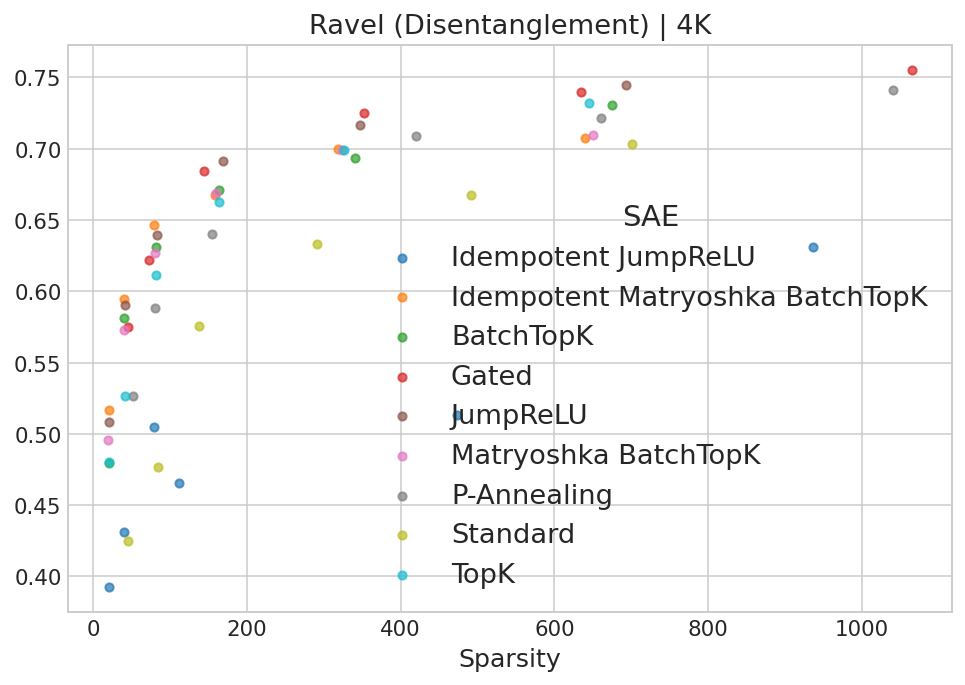

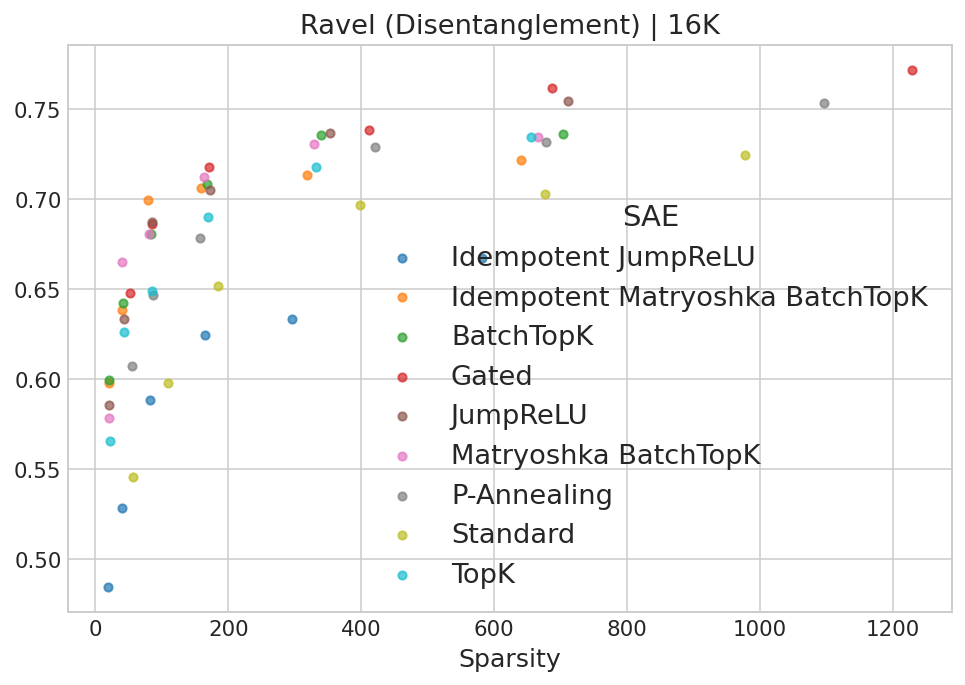

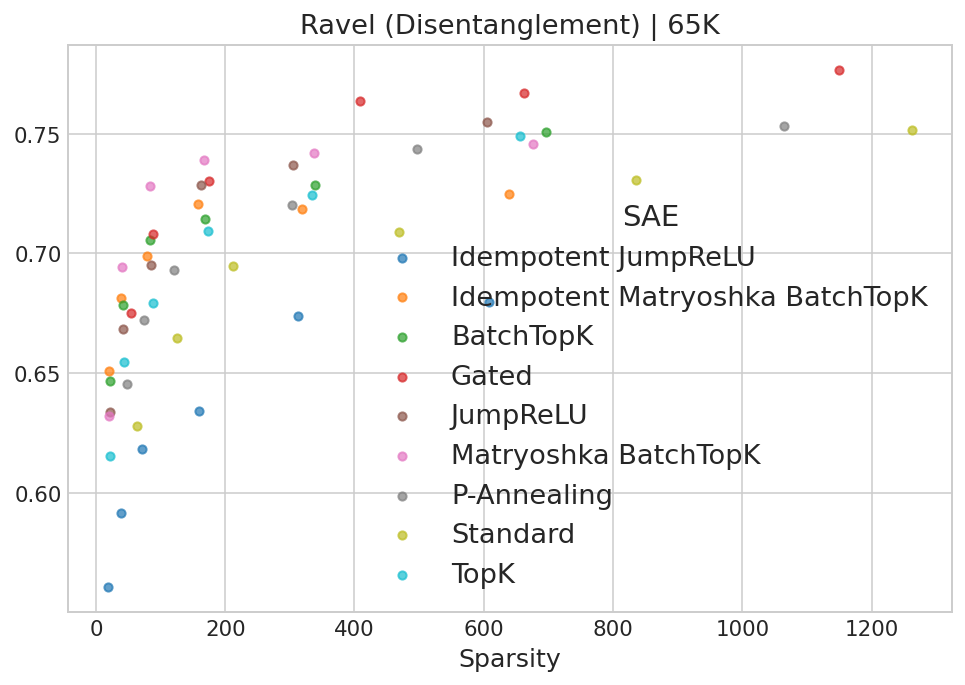

In [17]:
# Plot ravel disentanglement vs sparsity (one per width, colored by SAE)
plt.style.use("seaborn-v0_8-whitegrid")

all_classes_rv = sorted(df_rv_plot["saeClass"].dropna().unique())
pretty_sae = globals().get("pretty_sae", {})

cmap = plt.get_cmap("tab10", max(len(all_classes_rv), 1))
class_to_color = {cls: cmap(i) for i, cls in enumerate(all_classes_rv)}

use_log_x = df_rv_plot["l0"].max() / max(df_rv_plot["l0"].min(), 1e-12) > 100

for d in sorted(df_rv_plot["dSae"].dropna().unique()):
    dfi = df_rv_plot[df_rv_plot["dSae"] == d]

    fig, ax = plt.subplots(figsize=(7, 5), dpi=140)

    for cls in all_classes_rv:
        sub = dfi[dfi["saeClass"] == cls]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["l0"],
            sub["disentanglement_score"],
            s=18,
            alpha=0.7,
            color=class_to_color[cls],
            label=pretty_sae.get(cls, cls),
        )

    ax.set_xlabel("Sparsity" + (" (log scale)" if use_log_x else ""))
    width = {4096: "4K", 16384: "16K", 65536: "65K"}.get(int(d), str(int(d)))
    ax.set_title(f"Ravel (Disentanglement) | {width}")

    if use_log_x:
        ax.set_xscale("log")

    ax.legend(title="SAE", loc="best")
    fig.tight_layout()
    plt.show()

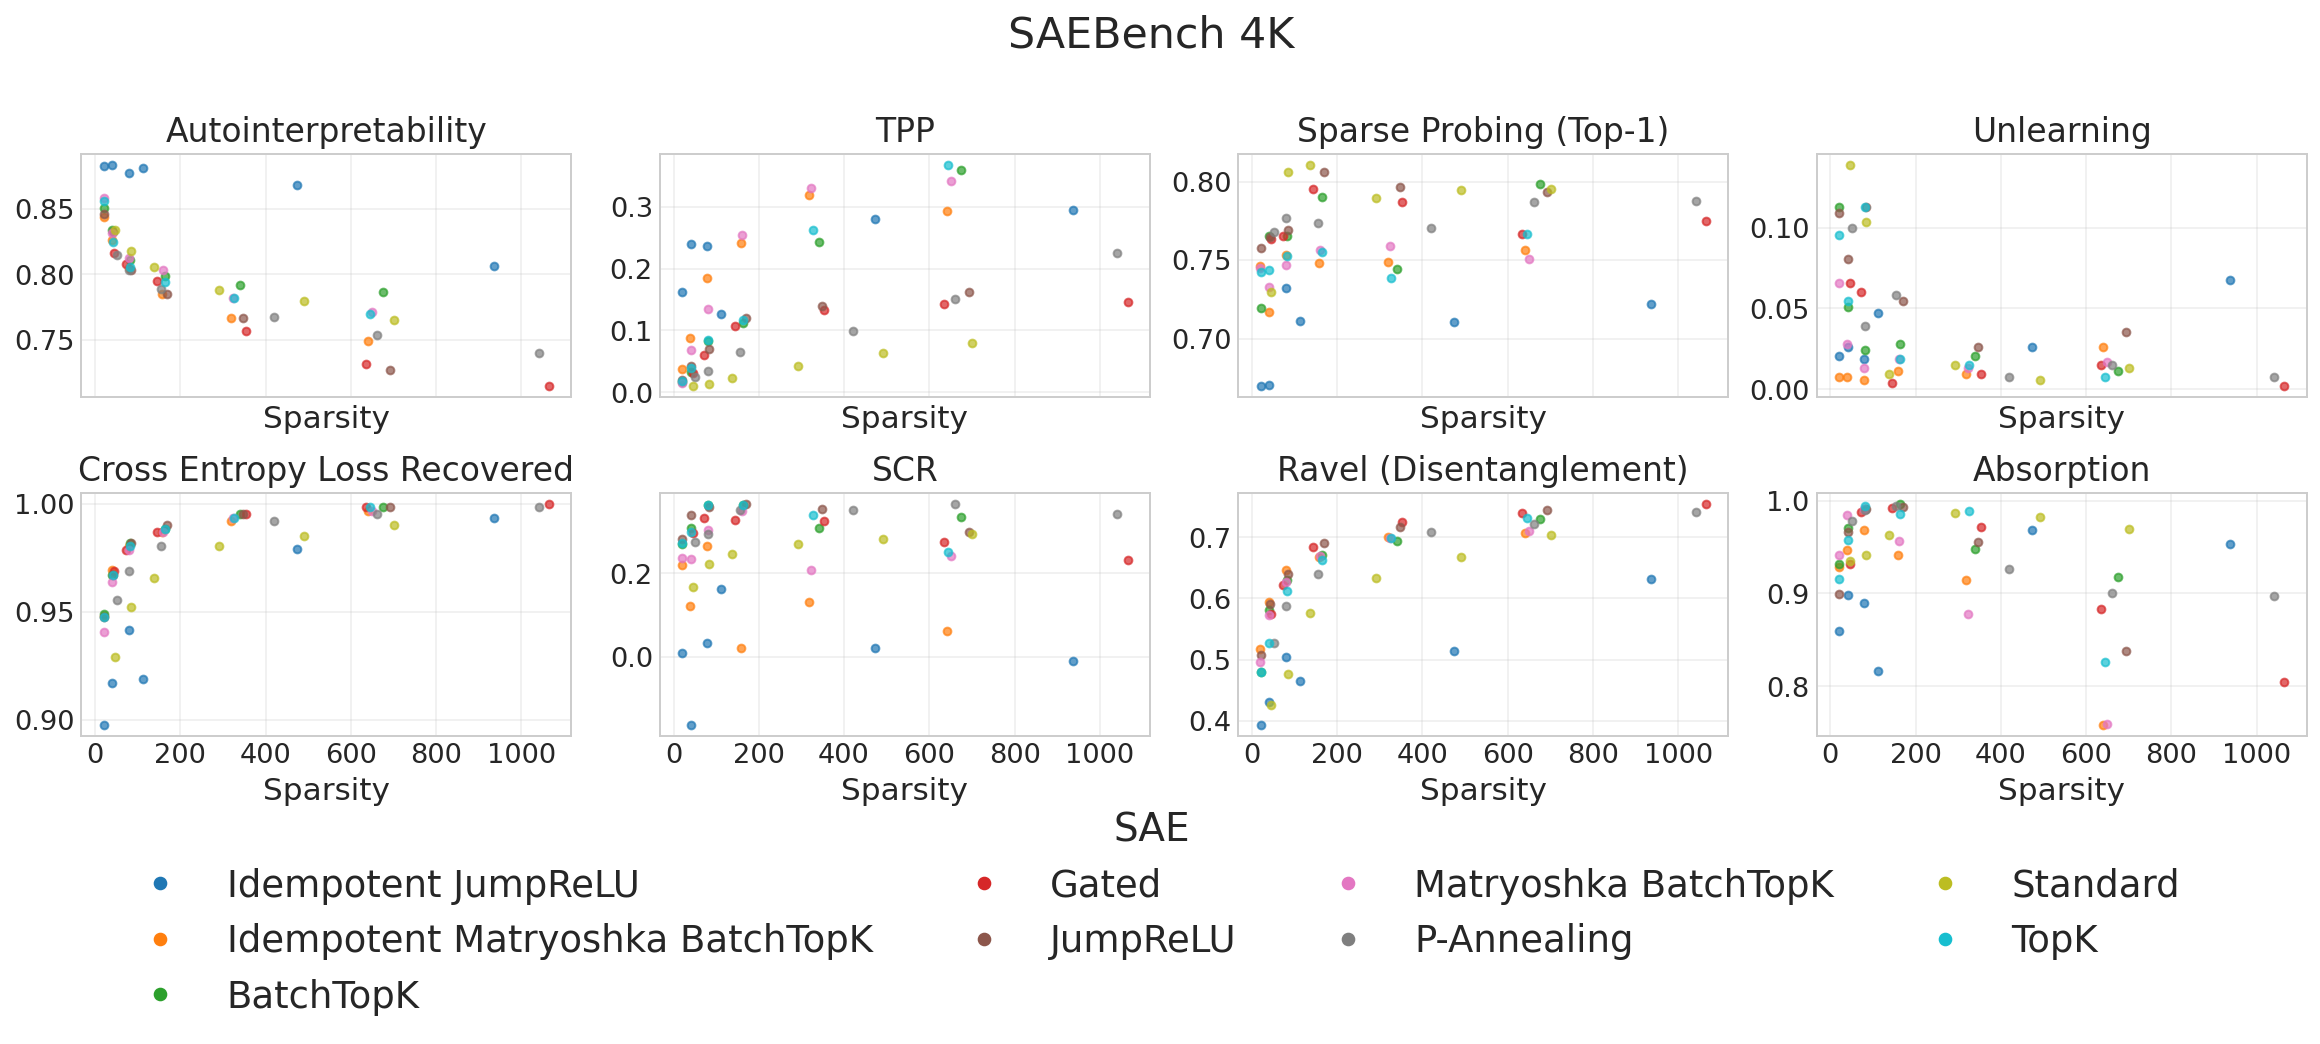

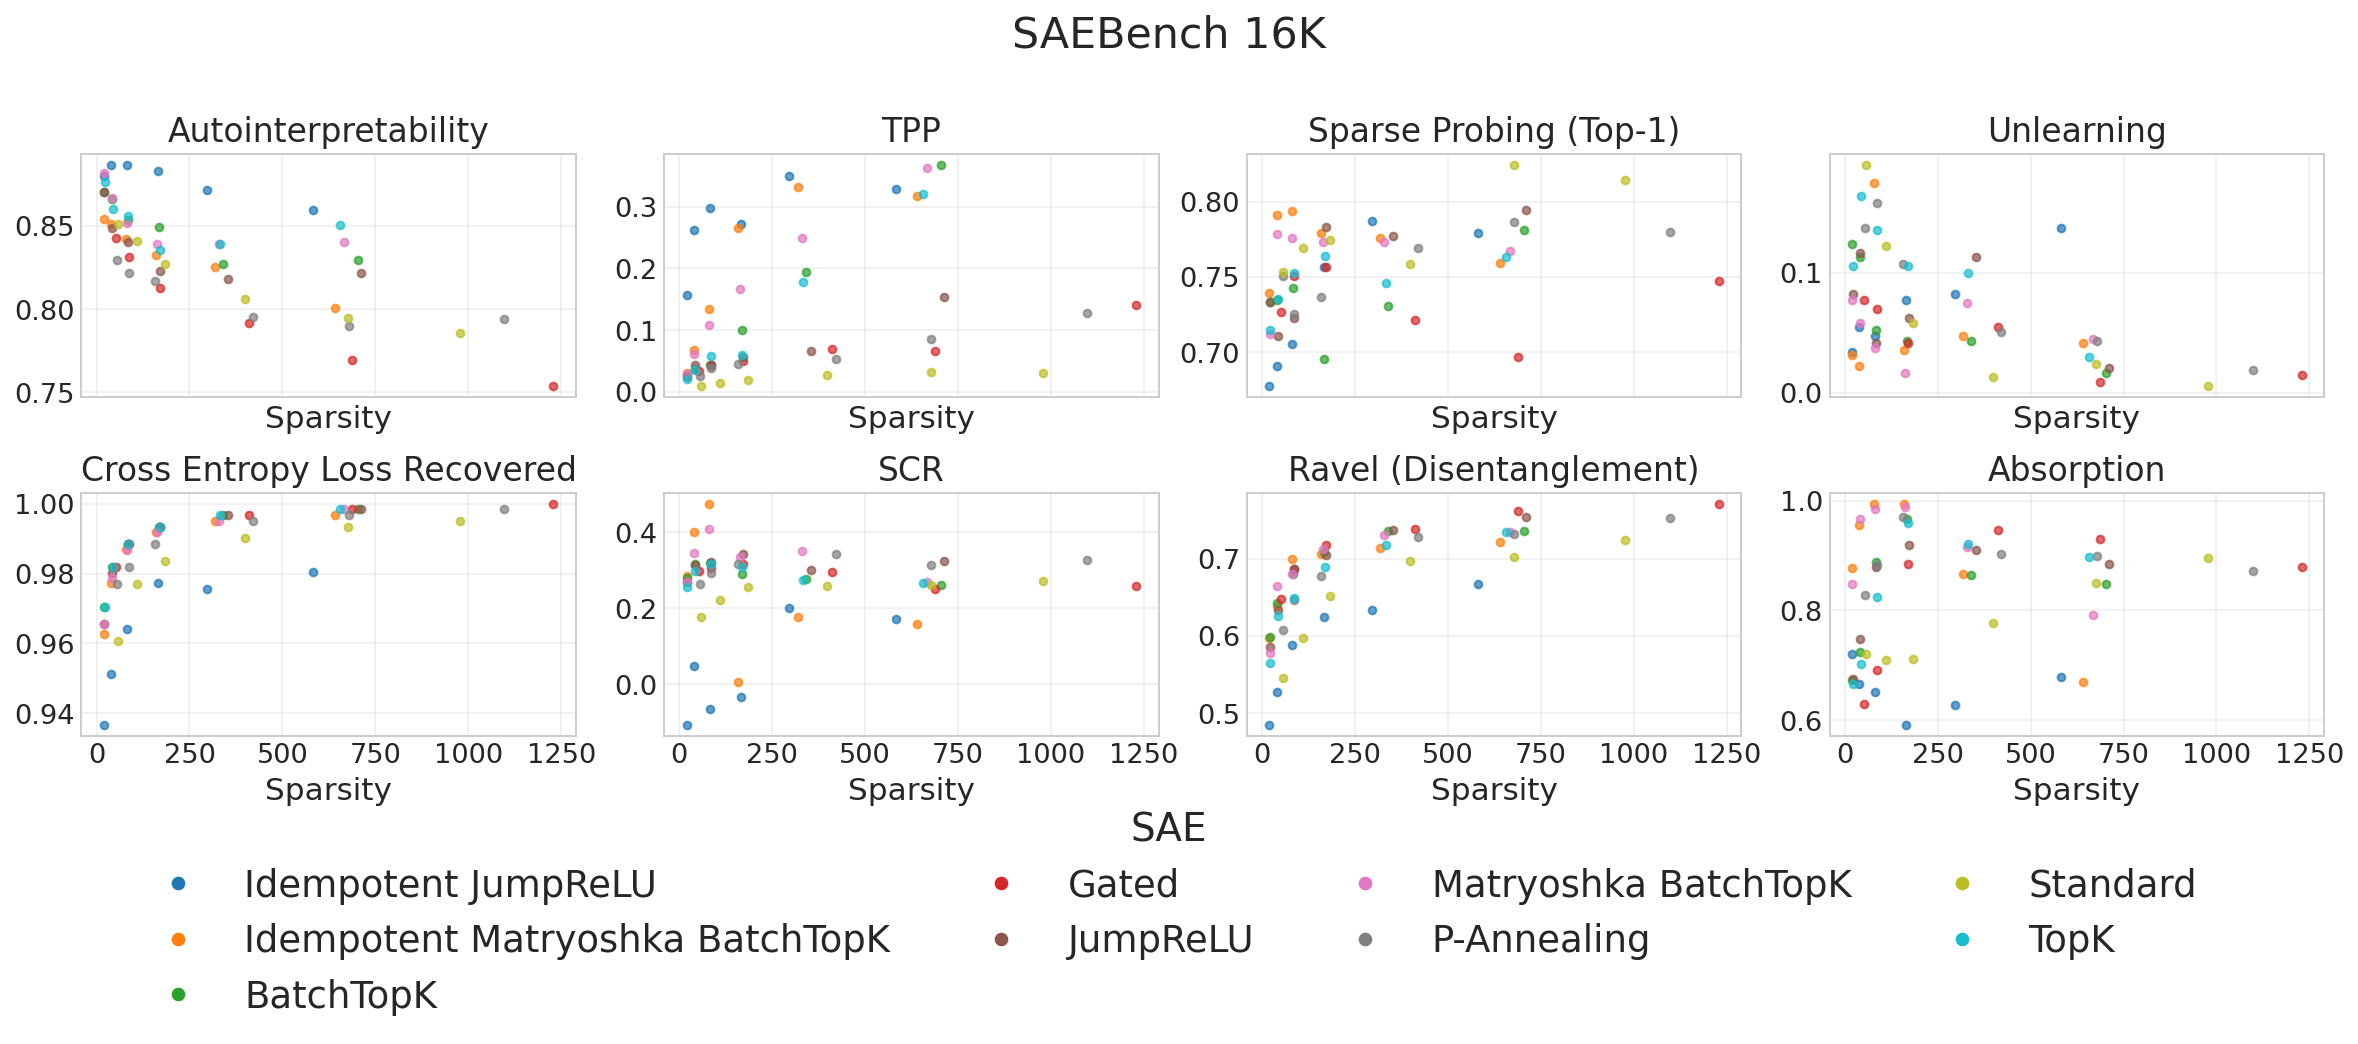

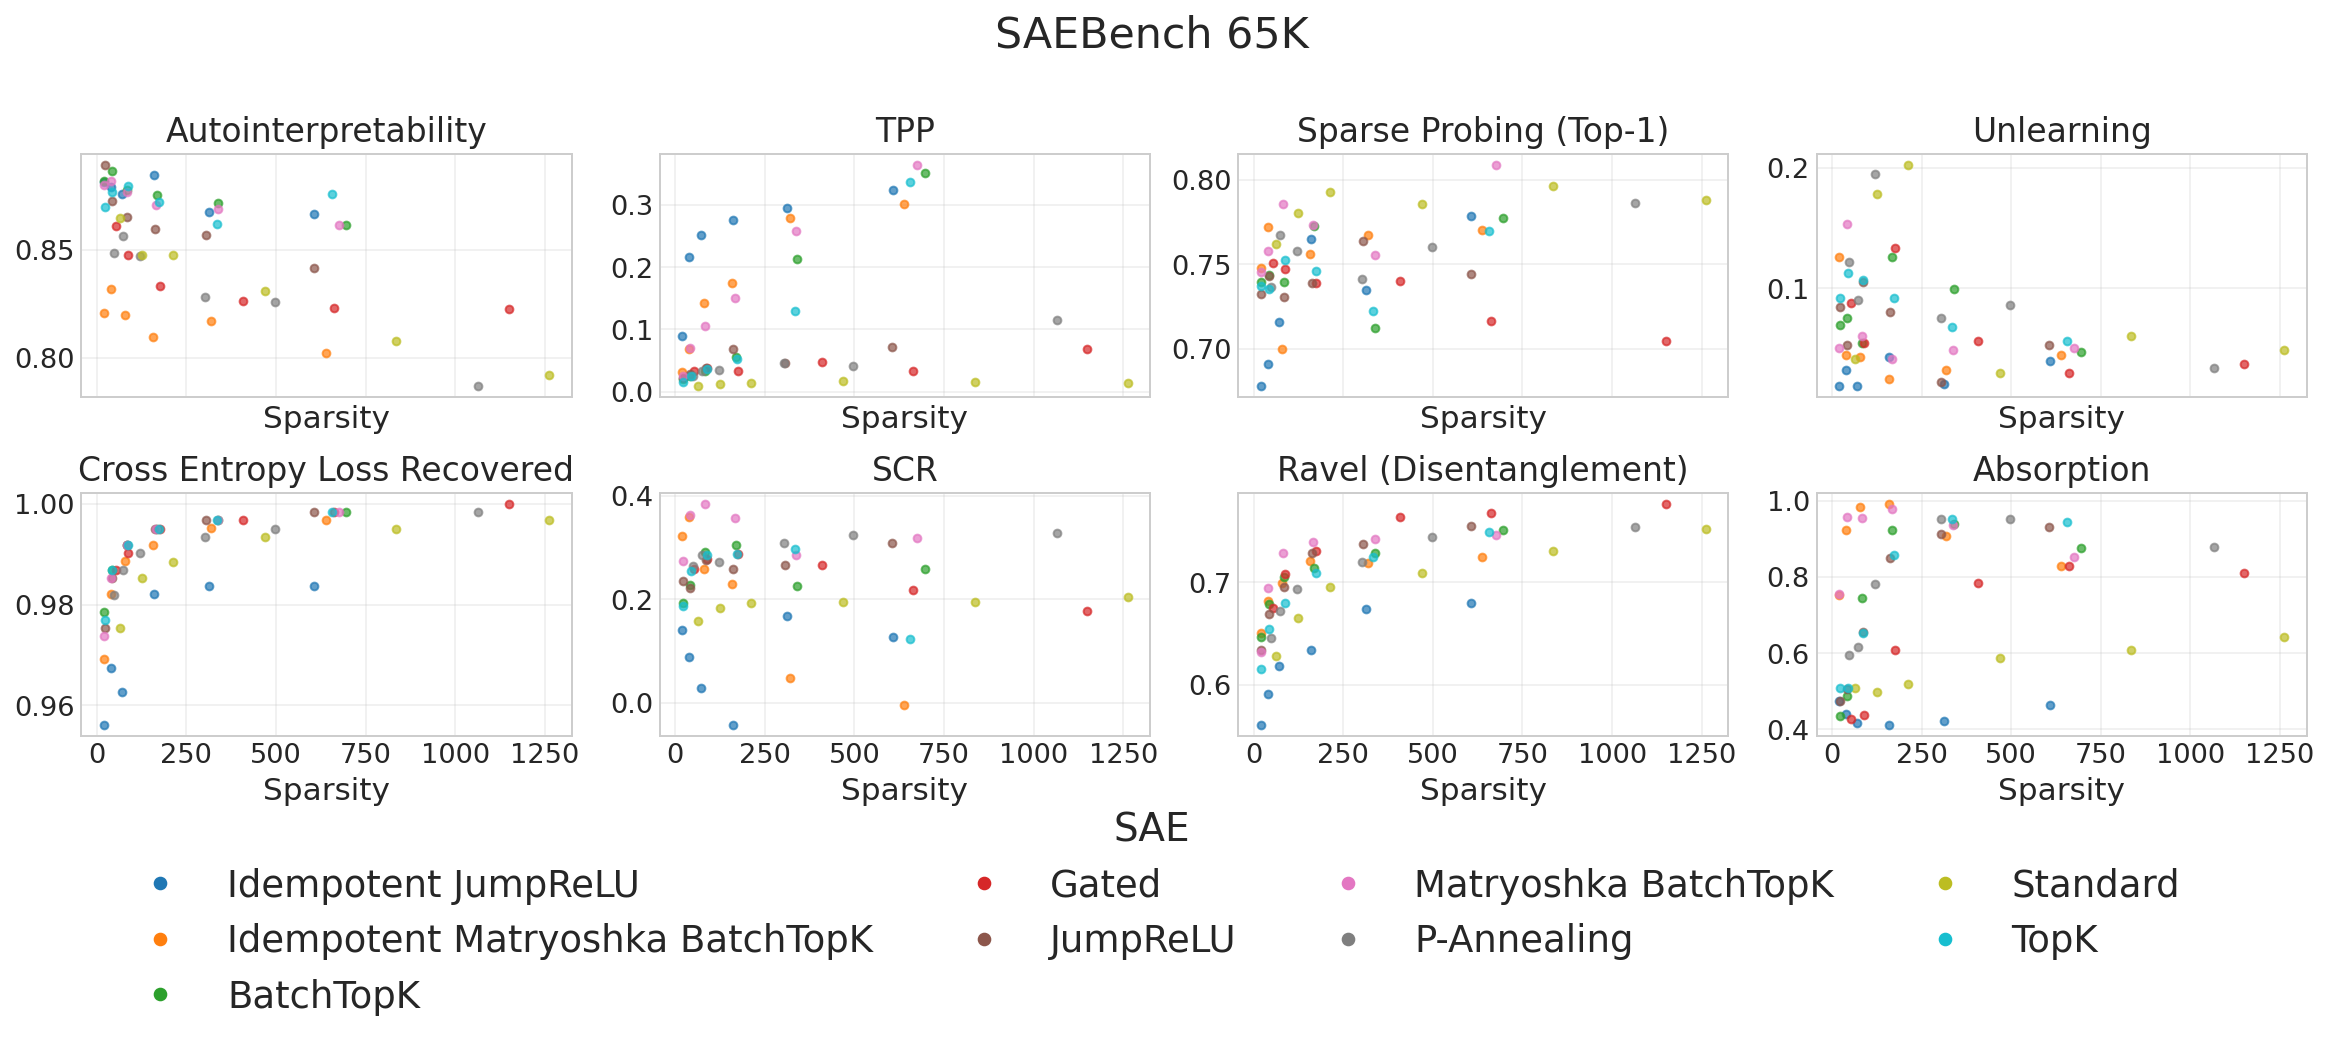

In [20]:
# Summary: all metrics for a given width in one figure
plt.style.use("seaborn-v0_8-whitegrid")

# Larger fonts for multiplot figures (overrides global rcParams for these cells)
_MFS_SUP, _MFS_SUB = 22, 17
_MFS_LBL, _MFS_TICK = 16, 14
_MFS_LEG, _MFS_LEGT = 19, 20

# (subplot title, dataframe, y-column)
metric_panels = [
    ("Autointerpretability", df_auto_plot, "autointerp_score"),
    ("TPP", df_tpp_plot, "tpp_threshold_20_total_metric"),
    ("Sparse Probing (Top-1)", df_sp_plot, "sae_top_1_test_accuracy"),
    ("Unlearning", df_un_plot, "unlearning_score"),
    ("Cross Entropy Loss Recovered", df_plot, "ce_loss_score"),
    ("SCR", df_scr_plot, "scr_metric_threshold_20"),
    ("Ravel (Disentanglement)", df_rv_plot, "disentanglement_score"),
    ("Absorption", df_abs_plot, "one_minus_absorption"),
]

width_map = {4096: "4K", 16384: "16K", 65536: "65K"}

# Union of SAE classes across all panels for consistent colors
all_classes = sorted(
    {
        cls
        for _, dfi, _ in metric_panels
        for cls in dfi["saeClass"].dropna().unique().tolist()
    }
)
pretty_sae = globals().get("pretty_sae", {})

cmap = plt.get_cmap("tab10", max(len(all_classes), 1))
class_to_color = {cls: cmap(i) for i, cls in enumerate(all_classes)}

# Decide log-scale for x globally
all_l0 = np.concatenate([dfi["l0"].to_numpy() for _, dfi, _ in metric_panels])
use_log_x = (np.nanmax(all_l0) / max(np.nanmin(all_l0), 1e-12)) > 100

for dsae in [4096, 16384, 65536]:
    # Only include panels that actually have data for this width
    panels_here = []
    for title, dfi, ycol in metric_panels:
        sub = dfi[dfi["dSae"] == dsae]
        if len(sub) == 0:
            continue
        panels_here.append((title, sub, ycol))

    if len(panels_here) == 0:
        continue

    n = len(panels_here)
    # 8 panels -> 2x4 layout
    ncols = 4
    nrows = 2

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(ncols * 4.2, nrows * 3.3),
        dpi=140,
        squeeze=False,
        sharex=True,
    )
    axes = axes.ravel()

    for ax_idx, (title, dfi, ycol) in enumerate(panels_here):
        ax = axes[ax_idx]
        for cls in all_classes:
            dcls = dfi[dfi["saeClass"] == cls]
            if len(dcls) == 0:
                continue
            ax.scatter(
                dcls["l0"],
                dcls[ycol],
                s=16,
                alpha=0.7,
                color=class_to_color[cls],
                label=pretty_sae.get(cls, cls),
            )
        ax.set_title(title, fontsize=_MFS_SUB)
        ax.grid(True, alpha=0.35)

    # Turn off any unused axes
    for k in range(len(panels_here), len(axes)):
        axes[k].axis("off")

    # X labeling
    for ax in axes:
        if ax.has_data():
            ax.set_xlabel(
                "Sparsity" + (" (log scale)" if use_log_x else ""),
                fontsize=_MFS_LBL,
            )
            ax.tick_params(axis="both", labelsize=_MFS_TICK)
            if use_log_x:
                ax.set_xscale("log")

    # Build legend entries in a stable order
    handles, labels = [], []
    for cls in all_classes:
        handles.append(
            plt.Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markersize=6,
                color=class_to_color[cls],
            )
        )
        labels.append(pretty_sae.get(cls, cls))

    # Shared legend below
    fig.legend(
        handles,
        labels,
        title="SAE",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.10),
        ncol=4,
        frameon=False,
        fontsize=_MFS_LEG,
        title_fontsize=_MFS_LEGT,
    )

    width = width_map.get(dsae, str(dsae))
    fig.suptitle(f"SAEBench {width}", y=1.02, fontsize=_MFS_SUP)
    fig.tight_layout(rect=[0, 0.14, 1, 1])

    out_path = Path("plots") / f"saebench_{width}_multiplot.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")

    plt.show()

/tmp/nix-shell.UmAaP0/ipykernel_2486959/1145670919.py:103: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


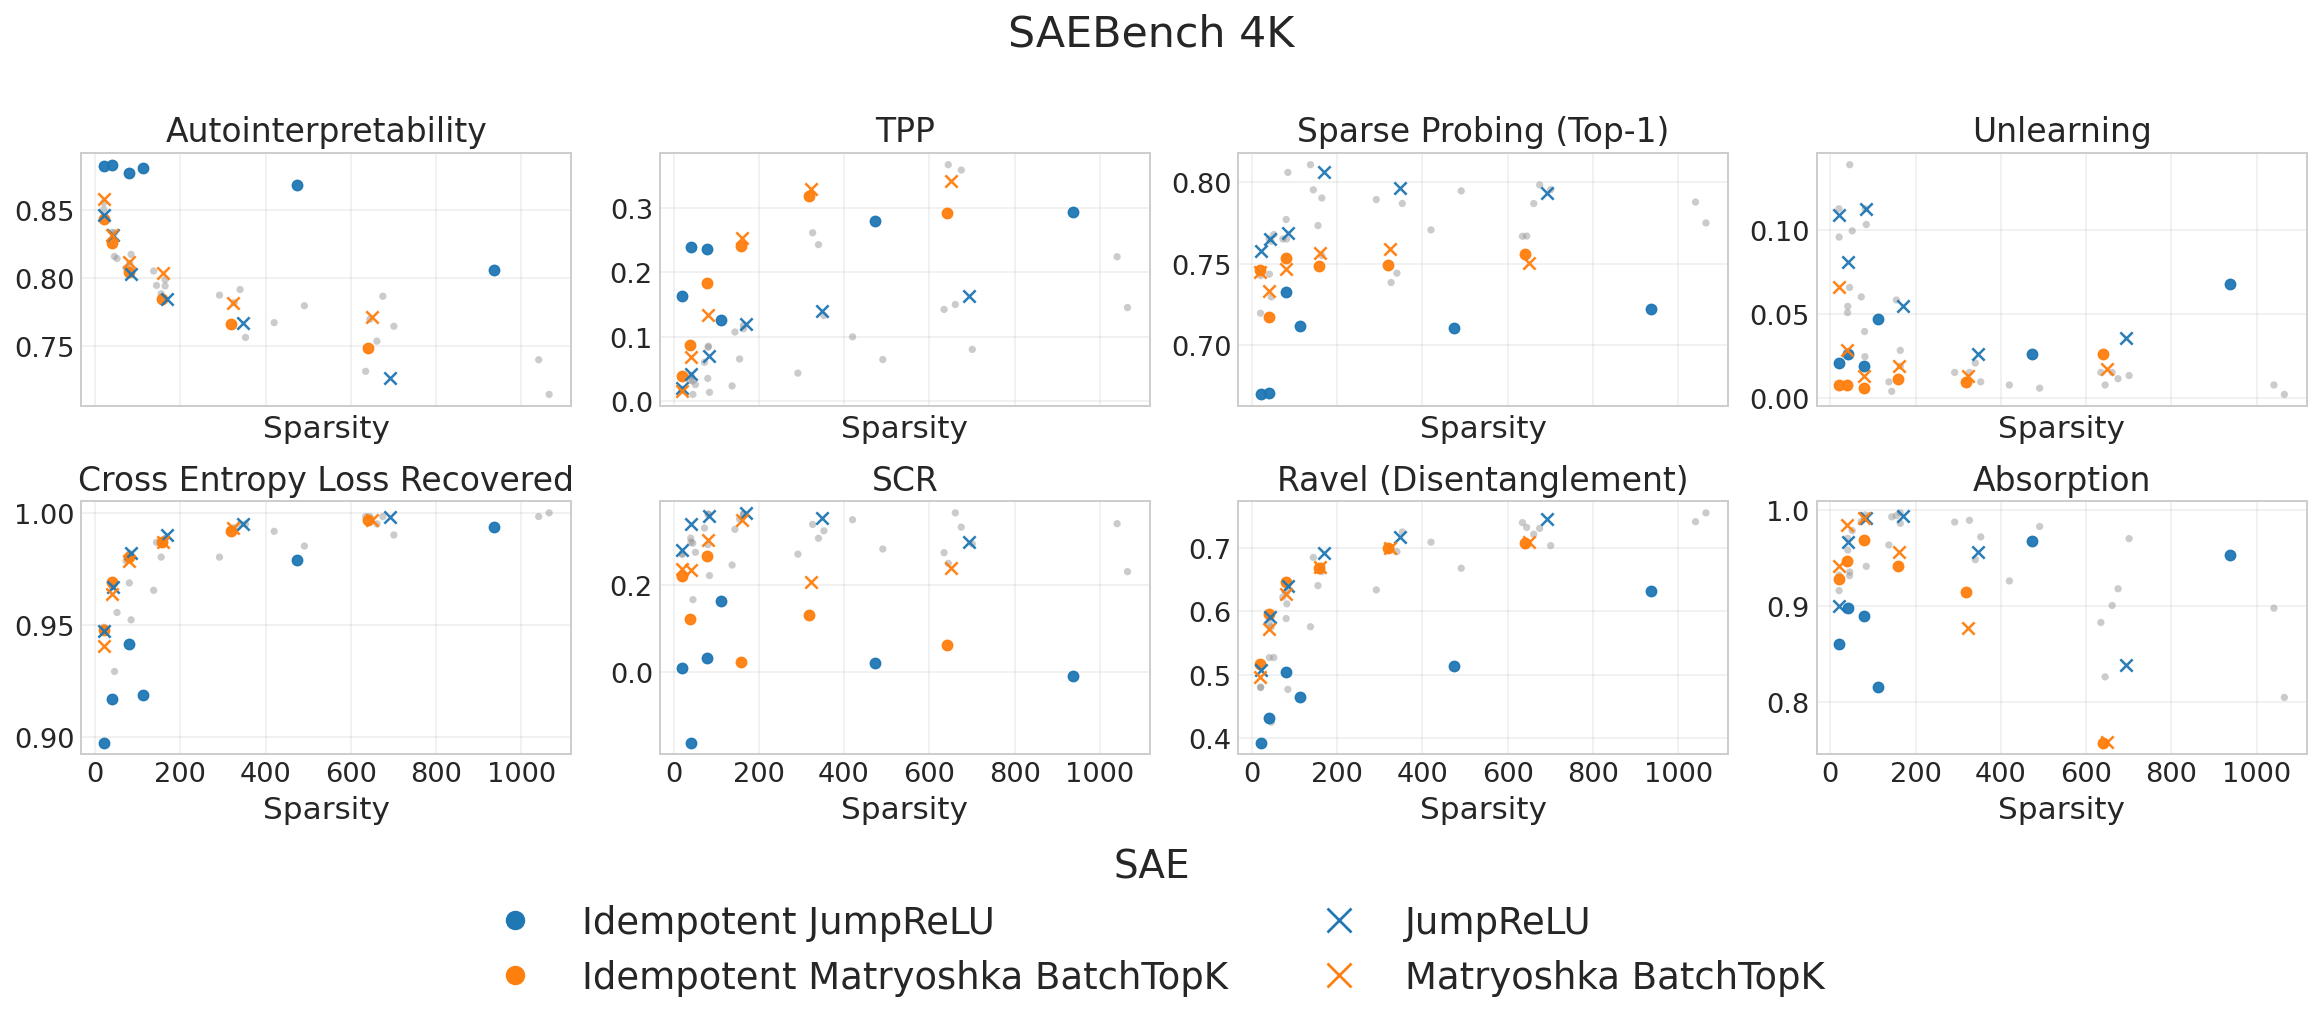

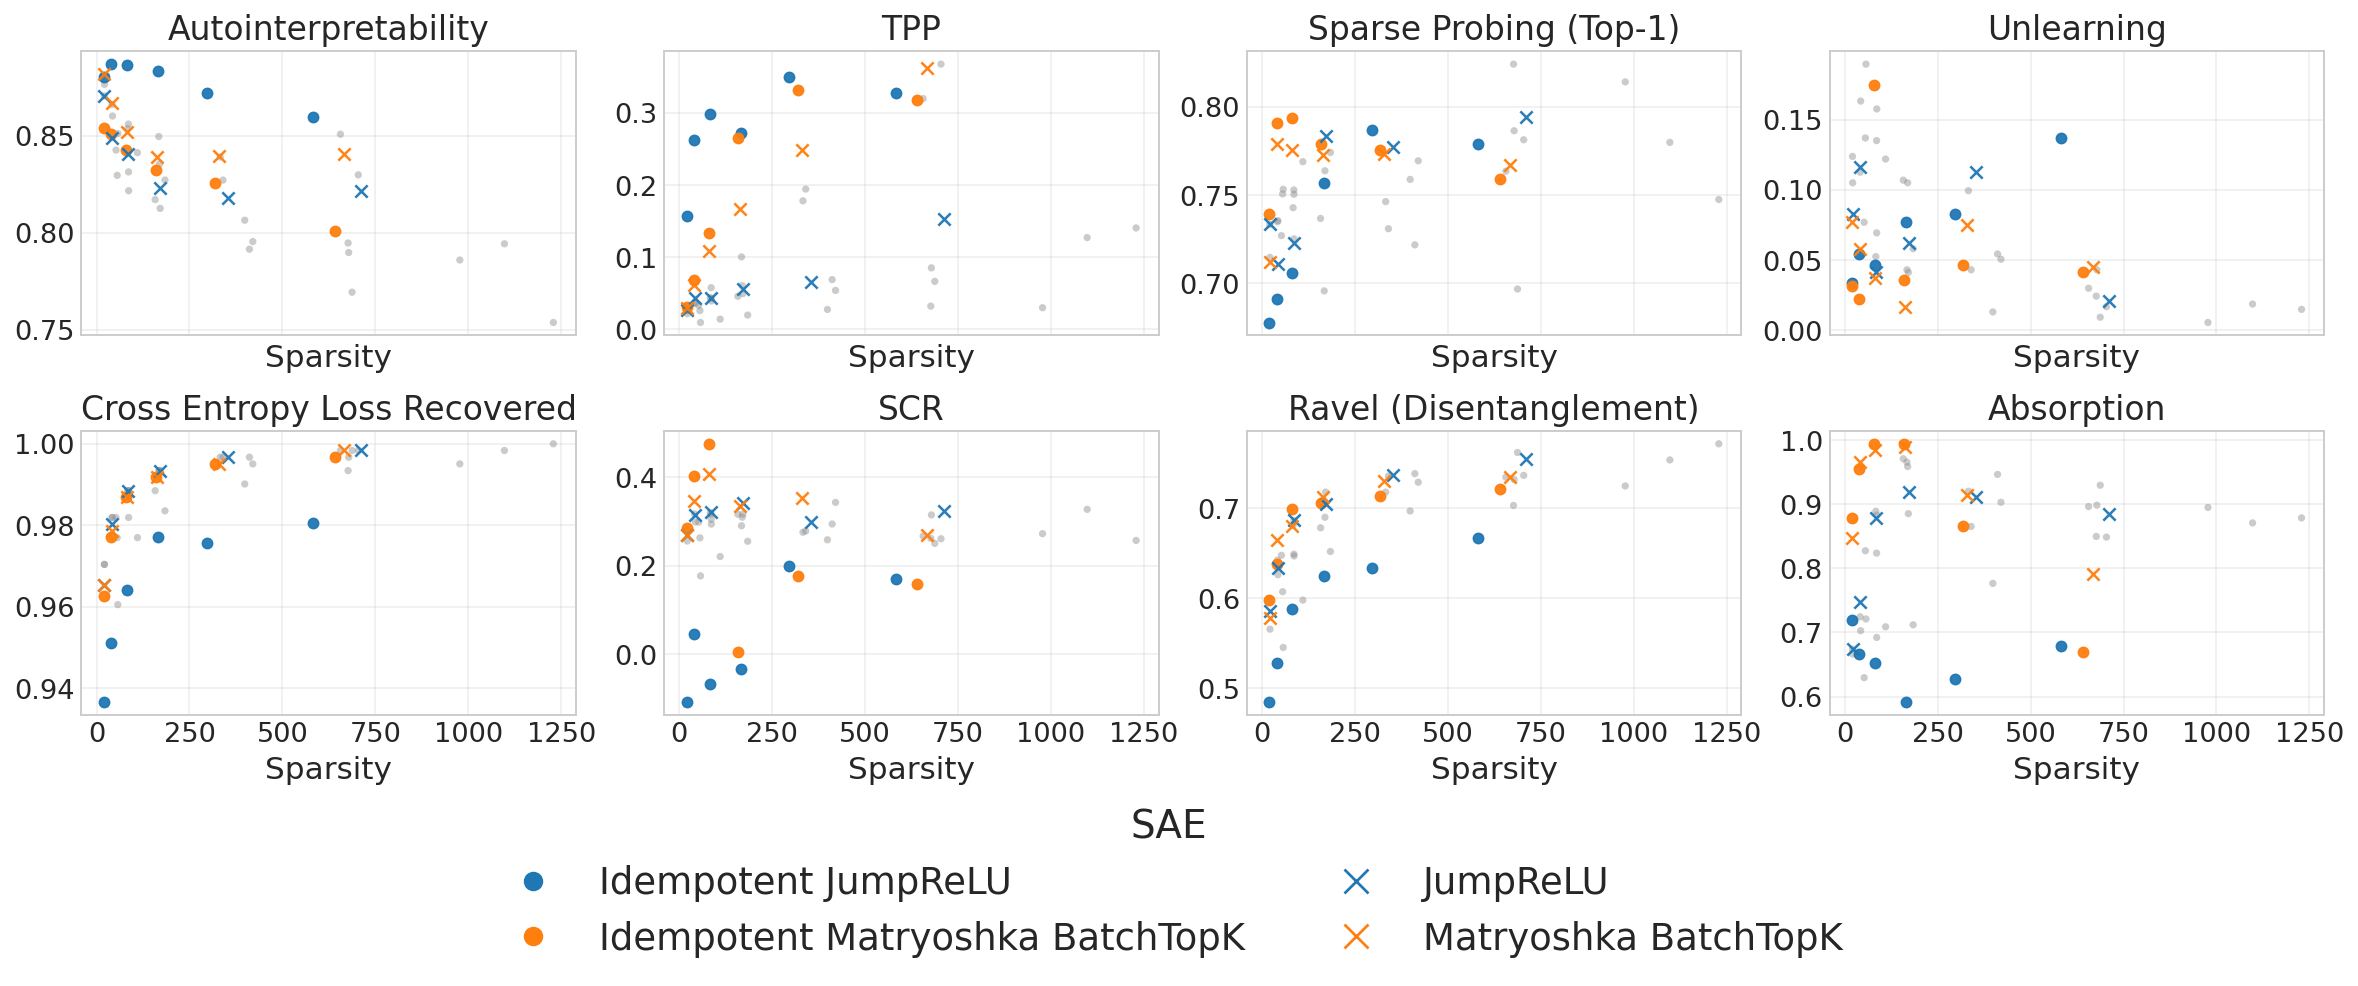

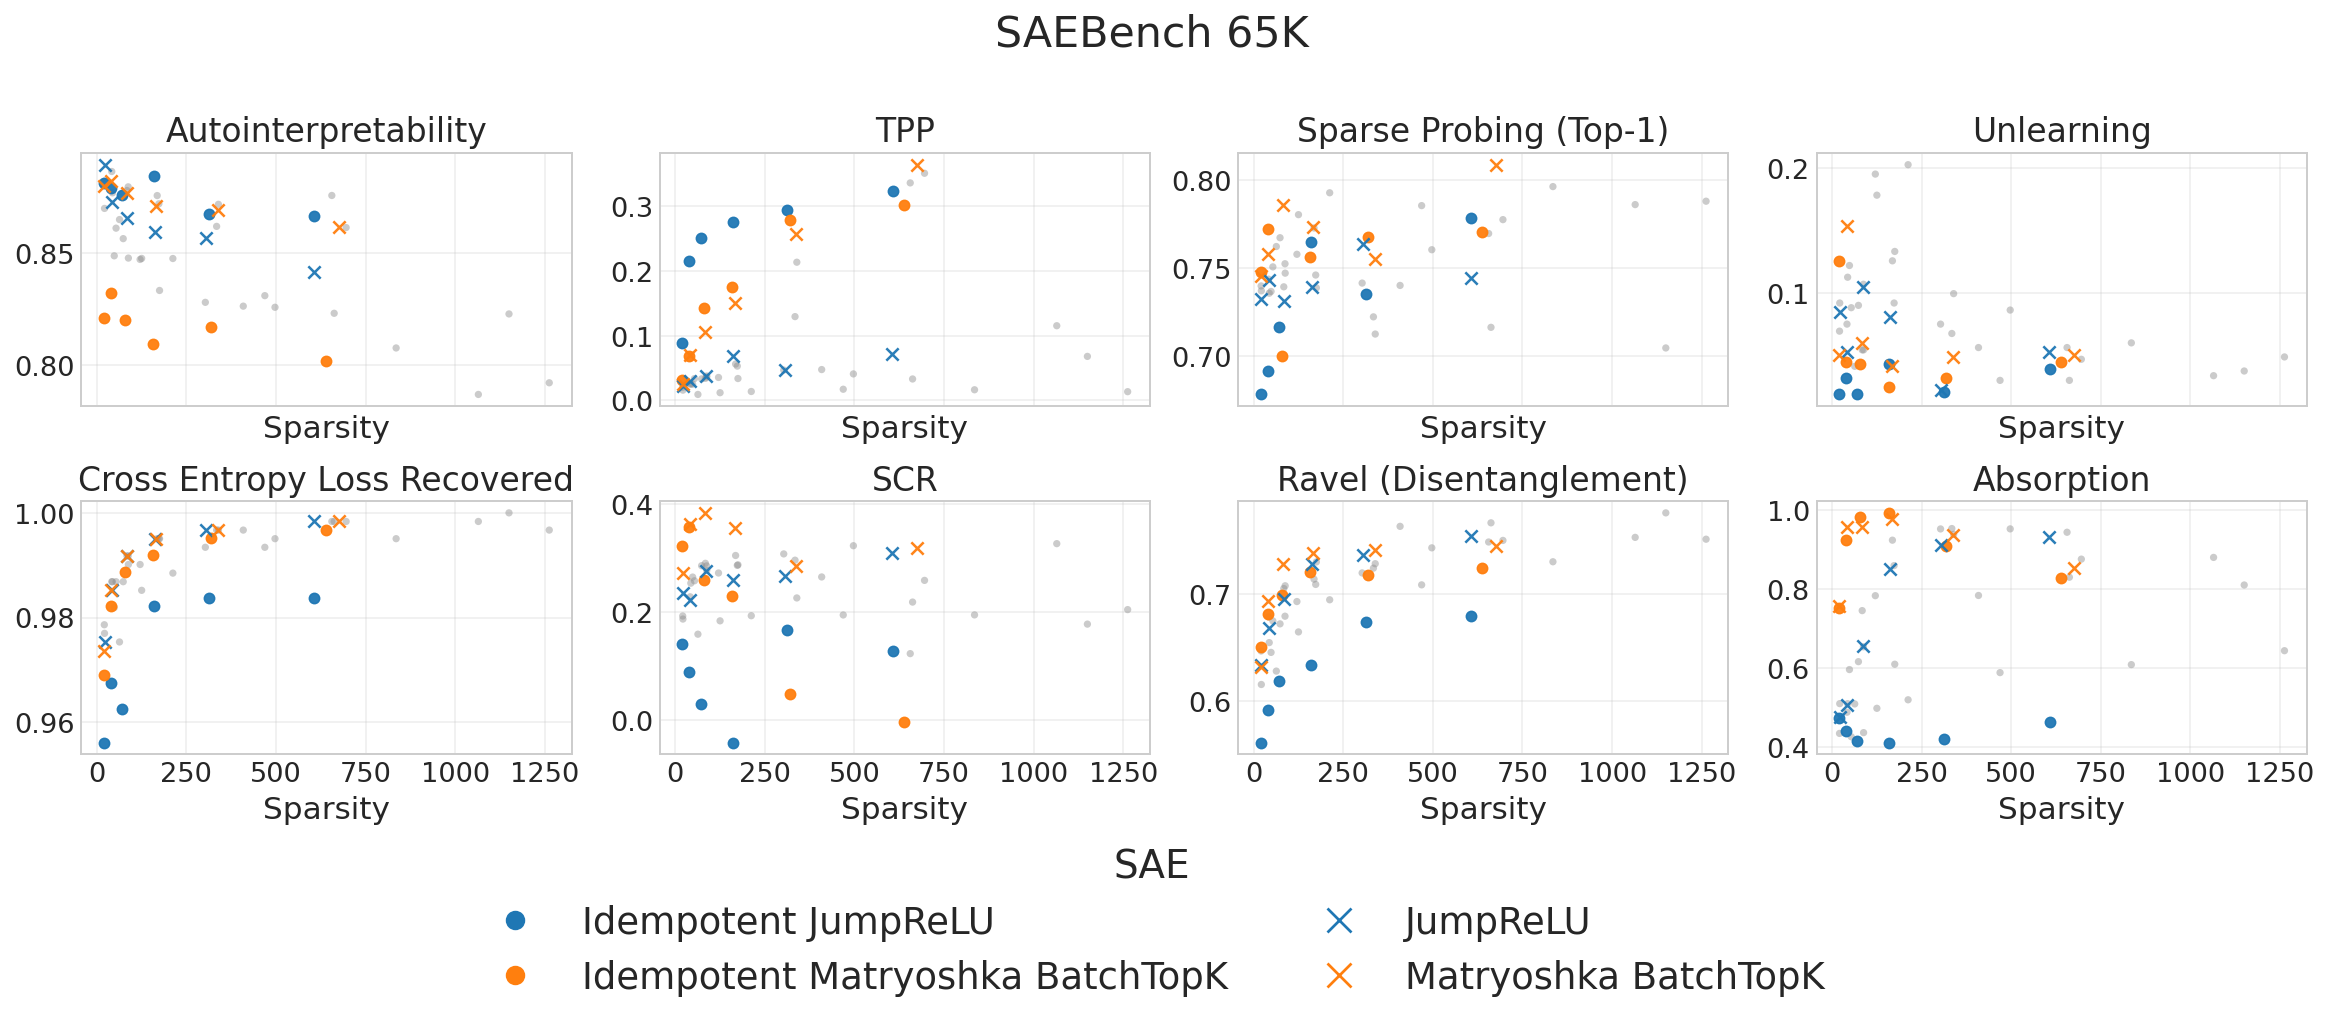

In [22]:
# Summary (focused): highlight selected SAEs, grey out others
plt.style.use("seaborn-v0_8-whitegrid")

# Larger fonts for multiplot figures
_MFS_SUP, _MFS_SUB = 22, 17
_MFS_LBL, _MFS_TICK = 16, 14
_MFS_LEG, _MFS_LEGT = 19, 20

metric_panels = [
    ("Autointerpretability", df_auto_plot, "autointerp_score"),
    ("TPP", df_tpp_plot, "tpp_threshold_20_total_metric"),
    ("Sparse Probing (Top-1)", df_sp_plot, "sae_top_1_test_accuracy"),
    ("Unlearning", df_un_plot, "unlearning_score"),
    ("Cross Entropy Loss Recovered", df_plot, "ce_loss_score"),
    ("SCR", df_scr_plot, "scr_metric_threshold_20"),
    ("Ravel (Disentanglement)", df_rv_plot, "disentanglement_score"),
    ("Absorption", df_abs_plot, "one_minus_absorption"),
]

width_map = {4096: "4K", 16384: "16K", 65536: "65K"}
pretty_sae = globals().get("pretty_sae", {})

# Target SAEs (raw keys as they appear in df_*['saeClass'])
TARGETS = [
    "IdempotentJumpRelu",
    "IdempotentMatryoshkaBatchTopK",
    "jumprelu",
    "matryoshka_batch_topk",
]

# Color encodes architecture (JumpReLU vs Matryoshka BatchTopK)
ARCH_COLOR = {
    "JumpReLU": plt.get_cmap("tab10")(0),
    "Matryoshka BatchTopK": plt.get_cmap("tab10")(1),
}

# Marker encodes idempotent vs non-idempotent
MARKER = {False: "x", True: "o"}

def _arch_for_cls(cls: str) -> str:
    if cls in ("IdempotentJumpRelu", "jumprelu"):
        return "JumpReLU"
    if cls in ("IdempotentMatryoshkaBatchTopK", "matryoshka_batch_topk"):
        return "Matryoshka BatchTopK"
    return "Other"

def _is_idempotent(cls: str) -> bool:
    return cls.startswith("Idempotent")

# Decide log-scale for x globally
all_l0 = np.concatenate([dfi["l0"].to_numpy() for _, dfi, _ in metric_panels])
use_log_x = (np.nanmax(all_l0) / max(np.nanmin(all_l0), 1e-12)) > 100

for dsae in [4096, 16384, 65536]:
    panels_here = []
    for title, dfi, ycol in metric_panels:
        sub = dfi[dfi["dSae"] == dsae]
        if len(sub) == 0:
            continue
        panels_here.append((title, sub, ycol))

    if len(panels_here) == 0:
        continue

    n = len(panels_here)
    # 8 panels -> 2x4 layout
    ncols = 4
    nrows = 2

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(ncols * 4.2, nrows * 3.3),
        dpi=140,
        squeeze=False,
        sharex=True,
    )
    axes = axes.ravel()

    for ax_idx, (title, dfi, ycol) in enumerate(panels_here):
        ax = axes[ax_idx]

        # Grey background: all non-target SAEs (less faded)
        bg = dfi[~dfi["saeClass"].isin(TARGETS)]
        if len(bg) > 0:
            ax.scatter(
                bg["l0"],
                bg[ycol],
                s=14,
                alpha=0.45,
                color="0.55",
                edgecolors="none",
            )

        # Highlight targets
        for cls in TARGETS:
            sub = dfi[dfi["saeClass"] == cls]
            if len(sub) == 0:
                continue
            arch = _arch_for_cls(cls)
            is_idem = _is_idempotent(cls)
            is_cross = MARKER[is_idem] == "x"
            ax.scatter(
                sub["l0"],
                sub[ycol],
                s=40 if is_cross else 28,
                alpha=0.95,
                color=ARCH_COLOR[arch],
                marker=MARKER[is_idem],
                linewidths=1.3 if is_cross else (0.8 if is_idem else 0.4),
                edgecolors="white" if not is_idem else None,
            )

        ax.set_title(title, fontsize=_MFS_SUB)
        ax.grid(True, alpha=0.35)

    # Empty axes off
    for k in range(len(panels_here), len(axes)):
        axes[k].axis("off")

    for ax in axes:
        if ax.has_data():
            ax.set_xlabel(
                "Sparsity" + (" (log scale)" if use_log_x else ""),
                fontsize=_MFS_LBL,
            )
            ax.tick_params(axis="both", labelsize=_MFS_TICK)
            if use_log_x:
                ax.set_xscale("log")

    # Shared legend below (targets only)
    handles = []
    labels = []
    for cls in TARGETS:
        arch = _arch_for_cls(cls)
        is_idem = _is_idempotent(cls)
        handles.append(
            plt.Line2D(
                [0],
                [0],
                marker=MARKER[is_idem],
                linestyle="",
                markersize=12 if MARKER[is_idem] == "x" else 9,
                markerfacecolor=ARCH_COLOR[arch] if MARKER[is_idem] != "x" else "none",
                markeredgecolor=ARCH_COLOR[arch],
                markeredgewidth=1.4 if MARKER[is_idem] == "x" else 1.0,
                color=ARCH_COLOR[arch],
            )
        )
        labels.append(pretty_sae.get(cls, cls))

    fig.legend(
        handles,
        labels,
        title="SAE",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=2,
        frameon=False,
        fontsize=_MFS_LEG,
        title_fontsize=_MFS_LEGT,
    )

    width = width_map.get(dsae, str(dsae))
    if dsae != 16384:
        fig.suptitle(f"SAEBench {width}", y=1.02, fontsize=_MFS_SUP)
    fig.tight_layout(rect=[0, 0.12, 1, 1])

    out_path = Path("plots") / f"saebench_{width}_multiplot_highlighted.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")

    plt.show()